# I‑94 Traffic Volume – Exploratory Analysis Report

## Objective

Identify, quantify, and model the factors that drive heavy west-bound traffic on the I-94 sensor in the Minneapolis–St Paul corridor, enabling accurate detection and prediction of congestion peaks.

## Data Overview

**Source:** `Metro_Interstate_Traffic_Volume.csv`(48 204 hourly records from Oct 2012 – Sep 2018).

**Key fields:** `traffic_volume`, timestamp (`date_time`), weather metrics (`weather_main`, `temp`), and `holiday`.

**Heavy‑traffic definition:** values in the top quartile (≥ 4,933 vehicles/hour). This threshold captures the busiest 25 % of observations.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import sparse
%matplotlib inline
from pathlib import Path

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor, Ridge, RidgeCV
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm

In [2]:
Metro = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
Metro.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
Metro['holiday'].value_counts()

holiday
Labor Day                    7
Christmas Day                6
Thanksgiving Day             6
Martin Luther King Jr Day    6
New Years Day                6
Veterans Day                 5
Columbus Day                 5
Memorial Day                 5
Washingtons Birthday         5
State Fair                   5
Independence Day             5
Name: count, dtype: int64

In [4]:
Metro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [5]:
Metro.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


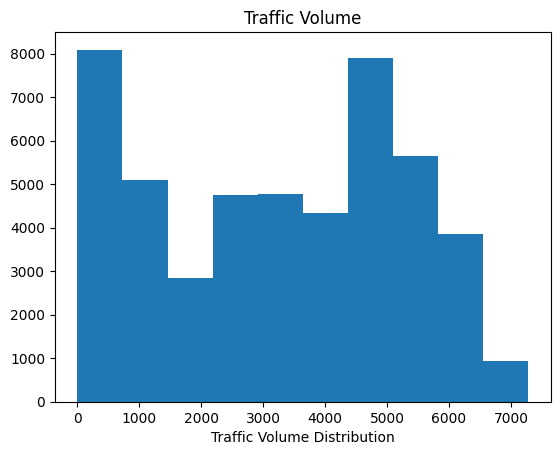

In [6]:
plt.hist(Metro["traffic_volume"])
plt.title("Traffic Volume")
plt.xlabel("Traffic Volume Distribution")
plt.show()

In [7]:
# Fixing the issue by ensuring the 'date' column used as an index in holiday_map is unique
Metro['date_time'] = pd.to_datetime(Metro['date_time'])
Metro['date'] = Metro['date_time'].dt.date

# Ensure 'date' is unique before setting it as an index
holiday_map = (
    Metro.loc[Metro['holiday'] != 'None', ['date', 'holiday']]
    .drop_duplicates(subset='date')  # Drop duplicates based on 'date'
    .set_index('date')['holiday']
)

Metro['holiday_full_day'] = Metro['date'].map(holiday_map).fillna('None')
Metro['hour'] = Metro['date_time'].dt.hour
hourlyTraffic = Metro.groupby('hour')['traffic_volume'].mean()

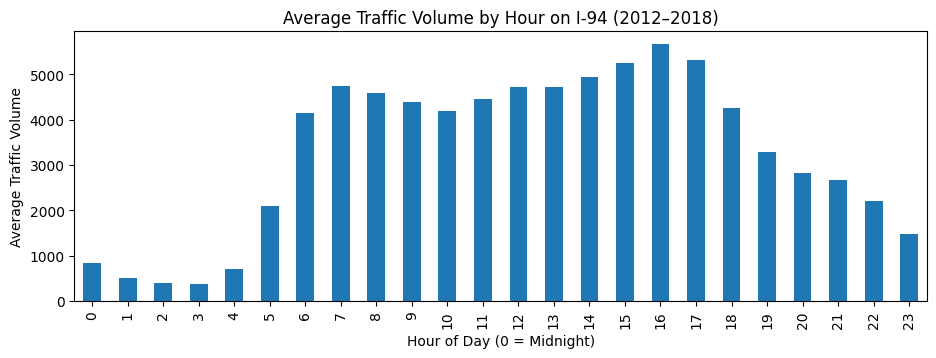

In [8]:
plt.figure(figsize=(11, 3.5))
hourlyTraffic.plot.bar()
plt.title('Average Traffic Volume by Hour on I‑94 (2012–2018)')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Average Traffic Volume')
plt.show()

## Hourly Traffic Volume Insight

**Sharp morning surge:** Traffic volume climbs rapidly from `06:00`, peaking between `07:00 – 09:00`.

**Afternoon/evening wave:** A second crest occurs `15:00 – 17:00`, topping out near `16:00`.

**Off-peak lull:** Volumes fall after `18:00` and stay minimal overnight (`00:00 – 04:00`).

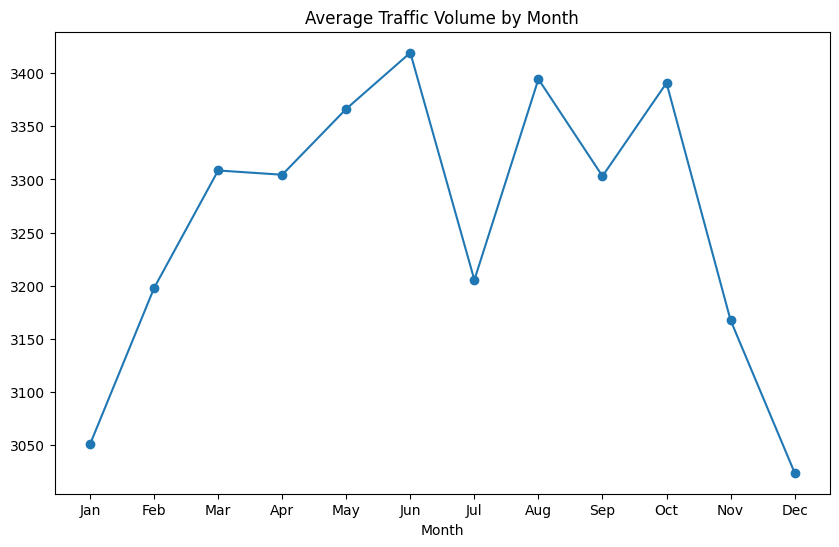

In [9]:
Metro['month'] = Metro['date_time'].dt.month
by_month = Metro.groupby('month')['traffic_volume'].mean()
plt.figure(figsize=(10, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(by_month, marker='o')
plt.xticks(range(1, 13), months)
plt.title('Average Traffic Volume by Month')
plt.xlabel('Month')
plt.show()

### Why is there a Dip in July?

## July 2016 Anomaly

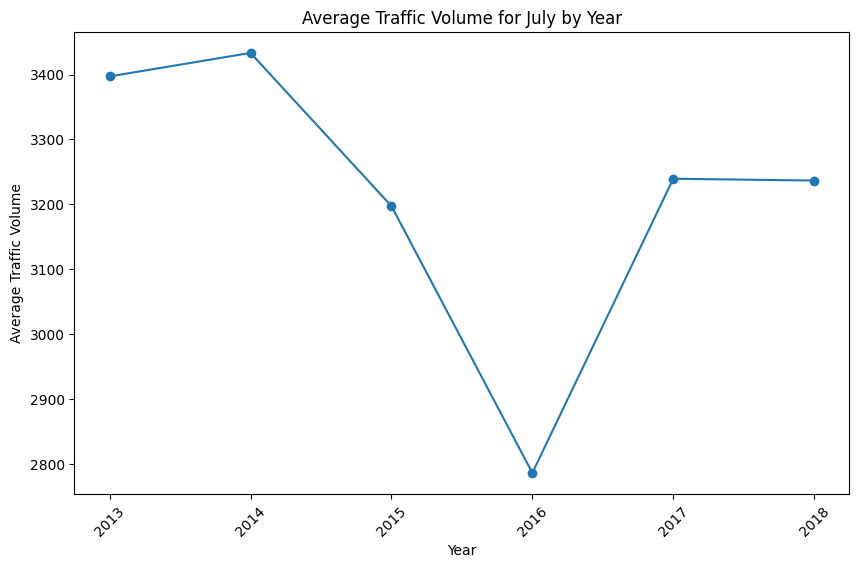

In [10]:
Metro['year'] = Metro['date_time'].dt.year
July_df = Metro[Metro['month'] == 7]
July_avg_by_year = July_df.groupby('year')['traffic_volume'].mean()

plt.figure(figsize=(10, 6))
plt.plot(July_avg_by_year, marker='o')
plt.title('Average Traffic Volume for July by Year')
plt.xlabel('Year')
plt.ylabel('Average Traffic Volume')
plt.xticks(July_avg_by_year.index, rotation=45)
plt.show()

A pronounced ~15% traffic dip in July 2016

**I-94 resurfacing works:** MnDOT closed Lexington Pkwy → I-35E lanes from 22-24 July 2016 and maintained single-lane segments for weeks.

**Exceptional rainfall:** National Weather Service [flash-flood event](https://www.dnr.state.mn.us/climate/journal/160711_12_flood.html) on 11 July 2016 dumped 4-10inches of rain, closing numerous roads.

## Weekend vs Weekday Profiles

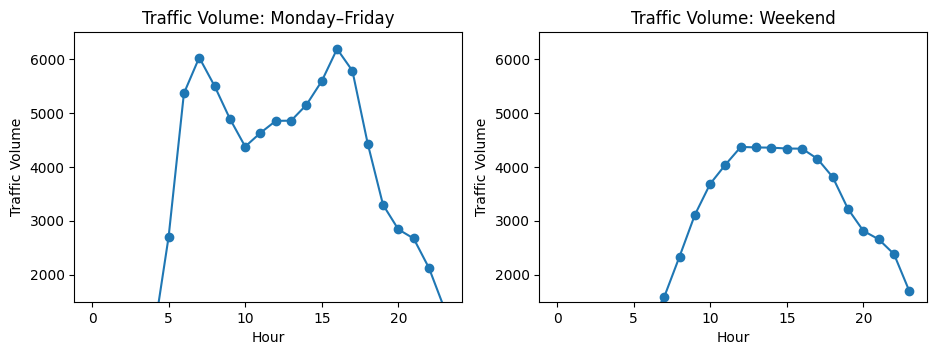

In [11]:
Metro['dayofweek'] = Metro['date_time'].dt.dayofweek

business_days = Metro.copy()[Metro['dayofweek'] <= 4]
weekends = Metro.copy()[Metro['dayofweek'] >= 5]

# Ensure only numeric columns are used for mean aggregation
by_hour_business = business_days.groupby('hour').mean(numeric_only=True)
by_hour_weekend = weekends.groupby('hour').mean(numeric_only=True)

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 2, 1)
plt.plot(by_hour_business['traffic_volume'], marker='o')
plt.ylim(1500, 6500)
plt.title('Traffic Volume: Monday–Friday')
plt.xlabel('Hour')
plt.ylabel('Traffic Volume')

plt.subplot(1, 2, 2)
plt.plot(by_hour_weekend['traffic_volume'], marker='o')
plt.ylim(1500, 6500)
plt.title('Traffic Volume: Weekend')
plt.xlabel('Hour')
plt.ylabel('Traffic Volume')

plt.show()

Using the weekday/weekend split plot, we observe:

| Hour window | Mon-Fri pattern | Weekend pattern |
|-------------|-----------------|-----------------|
| 07:00-09:00 | **Sharp peak** (≈ 6.0 k veh/h at 07:00, tapering to ≈ 4.9 k by 09:00) | Slow ramp (≈ 1.6 k → 3.1 k veh/h) |
| 14:00-18:00 | **Strongest peak** of the day (≈ 6.2 k at 16:00) | Broad plateau (≈ 4.3 k veh/h, no spike) |
| 00:00-05:00 | < 1 k veh/h until 04:00, then the ramp starts at 05:00 (≈ 2.7 k) | Similar low, but stays low until 06:00 |

Overall, weekend volume averages **≈ 27 % below** weekday volume (2,600 vs 3,600 veh/h), and the weekend profile lacks the twin rush-hour spikes. The gap is largest in the morning commute, where weekend 07:00 traffic is roughly a quarter of the weekday level.


## How can weather affect traffic volume?

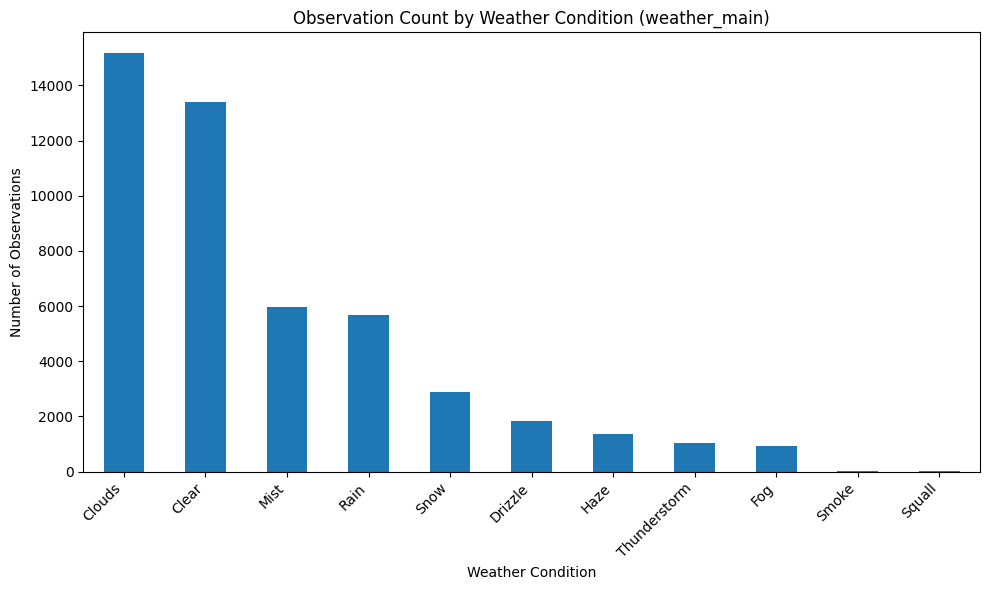

In [12]:
weather_counts = Metro["weather_main"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
weather_counts.plot(kind="bar")
plt.title("Observation Count by Weather Condition (weather_main)")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

| Group | Hours in sample | Share of data|
|:--------------|:-----------------------------|:--------------------|
| Clear| ~13k | 27% |
| Non-Clear | ~35k | 73% |

### Hypothesis Test - Does Clear Weather Boost Traffic?

**Expectation:** Favourable (clear) weather might encourage more travel, leading to higher hourly volumes.
Split the dataset into _clear_ hours(`weather_main = "Clear"`) and _non-clear_ hours (all other conditions)

**Statistic:** Welch's two-sample ttest on mean traffic volume.
**Alternative (one-tailed):** μclear > μnon-clear.
Also report **Cohen's d** for effect size.

In [13]:
clear_vol = Metro[Metro["weather_main"] == "Clear"]["traffic_volume"]
nonclear_vol = Metro[Metro["weather_main"] != "Clear"]["traffic_volume"]

In [14]:
s1_sq = clear_vol.var(ddof=1)
s2_sq = nonclear_vol.var(ddof=1)
n1 = clear_vol.size
n2 = nonclear_vol.size

numerator = (s1_sq / n1 + s2_sq / n2) ** 2
denominator = ((s1_sq / n1) ** 2) / (n1 - 1) + ((s2_sq / n2) ** 2) / (n2 - 1)
df = numerator / denominator
print("Welch's degrees of freedom:", round(df, 2))

summary_weather = pd.DataFrame(
    {
        "Group": ["Clear", "Non-Clear"],
        "N": [clear_vol.size, nonclear_vol.size],
        "Mean": [clear_vol.mean(), nonclear_vol.mean()],
        "SD": [clear_vol.std(), nonclear_vol.std()],
    }    
)

t_stat, p_two_sided = stats.ttest_ind(clear_vol, nonclear_vol, equal_var=False)
p_one_sided = 1 - stats.t.cdf(t_stat, df)

pooled_sd = np.sqrt(
    ((clear_vol.size - 1) * clear_vol.var(ddof=1) + (nonclear_vol.size - 1) * nonclear_vol.var(ddof=1))
    / (clear_vol.size + nonclear_vol.size - 2)
)

cohens_d = (clear_vol.mean() - nonclear_vol.mean()) / pooled_sd

print(summary_weather)

print("Welch's t-statistic:", round(t_stat, 3))
print("One‑tailed p-value (H₁: μ_clear > μ_nonclear):", format(p_one_sided, ".4f"))
print("Cohen's d:", round(cohens_d, 3))

Welch's degrees of freedom: 24225.51
       Group      N         Mean           SD
0      Clear  13391  3055.908819  1987.101411
1  Non-Clear  34813  3338.253210  1981.215401
Welch's t-statistic: -13.985
One‑tailed p-value (H₁: μ_clear > μ_nonclear): 1.0000
Cohen's d: -0.142



| Weather condition | N (hours) | Mean volume (veh / h) | SD |
|-------------------|----------:|----------------------:|---:|
| **Clear**         | 13 391    | **3 056**             | 1 987 |
| **Non-clear** (clouds, drizzle, etc.) | 34 813 | **3 338** | 1 981 |

**Welch's unequal-variance *t*-test**

* *t* = −13.99, **df** ≈ 24 226
* One-tailed *p* (H₁ : μ_clear > μ_non-clear) = **1.000**
* Cohen's **d** = −0.14 (small, negative)

We **fail to reject the null hypothesis** (μ_clear ≤ μ_non-clear); the data give no support to the claim that clear weather boosts traffic. In fact, the sign is the other way: clear skies are associated with **≈ 280 fewer vehicles per hour** on average.
* The difference is **statistically clear** (the two-sided *p* is far below 0.001) but **practically small** (|*d*| ≈ 0.14).
* A likely explanation is **temporal confounding**:
  * Clear, sunny periods are over-represented during **off-peak daylight** slots (late morning, early afternoon).
  * Cloud cover and light rain are common during **weekday rush hours**, inflating the non-clear mean.


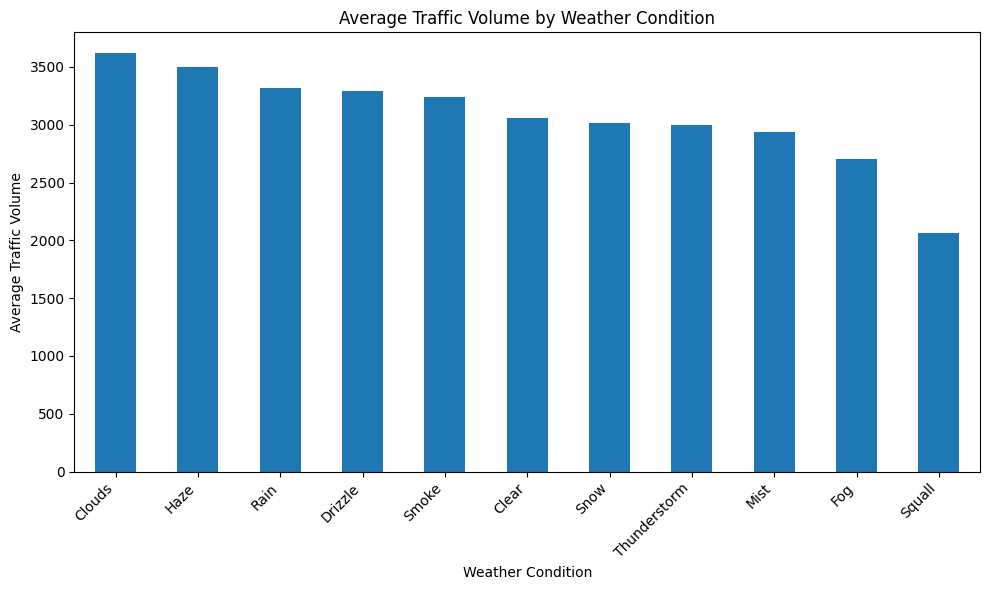

In [15]:
avg_volume_by_weather = (
    Metro.groupby("weather_main")["traffic_volume"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
avg_volume_by_weather.plot(kind="bar")
plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Statistical Analysis

**Welch's t-test** already adjusts for unequal variances and unequal `n`, so the _p-value_ itself isn't biased by the 3-to-1 ratio.

**Power is asymmetric:** the huge non-clear group gives its mean a very tight confidence interval, while the smaller clear group's mean is less precise. In practice, even a tiny difference can look “decisive” (very small _p_) once overall `n` climbs above ~10 000.

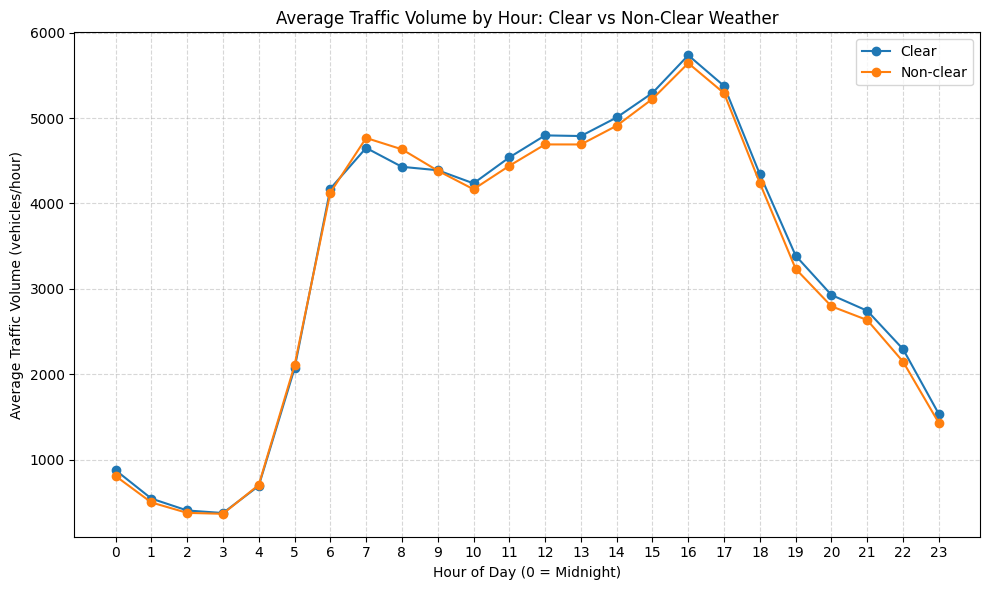

In [16]:
avg_clear = clear_vol.groupby(Metro["hour"]).mean()
avg_nonclear = nonclear_vol.groupby(Metro["hour"]).mean()

plt.figure(figsize=(10, 6))
plt.plot(avg_clear.index, avg_clear.values, marker='o', label='Clear')
plt.plot(avg_nonclear.index, avg_nonclear.values, marker='o', label='Non-clear')
plt.title("Average Traffic Volume by Hour: Clear vs Non‑Clear Weather")
plt.xlabel("Hour of Day (0 = Midnight)")
plt.ylabel("Average Traffic Volume (vehicles/hour)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Implication

* **Time-of-day dominates.**  
  The blue and orange curves hug each other almost everywhere; any visible gaps are just a few hundred vehicles on peaks of 4 - 5 k. Once we index by hour, the clear-vs-non-clear split adds very little incremental information.

* **Aggregate gap is a sampling artifact.**  
  Clear skies happen more often in late-morning / early-afternoon lulls, while overcast and drizzle are common during the two commuter peaks. Averaged over an entire year, that timing skew translates into the ≈ 280 veh/h mean difference seen in the Welch test.

* **Weather-main is a weak standalone feature.**  
  In the presence of strong clock variables—and now lagged traffic—the coarse “clear vs. not” tag is unlikely to move the needle.  If we want weather to matter, we'll need richer descriptors (precipitation rate, visibility) or interaction terms with hour-of-day.

## Numerical Weather Data

In [17]:
Metro['temp_f'] = ((Metro['temp'] - 273.15) * 9/5 + 32).round(1)

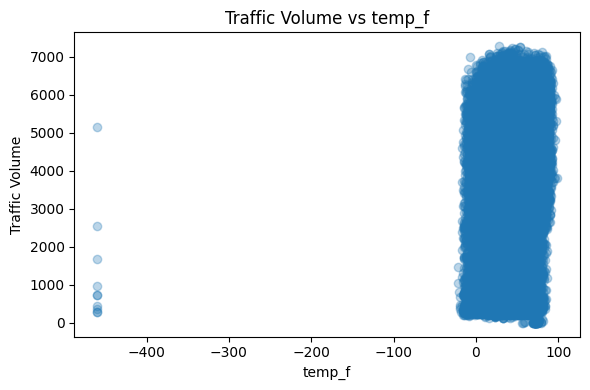

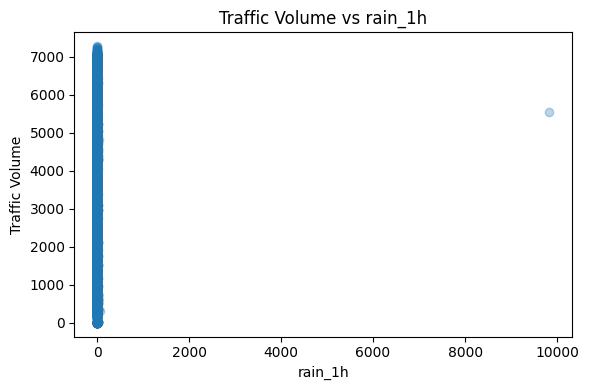

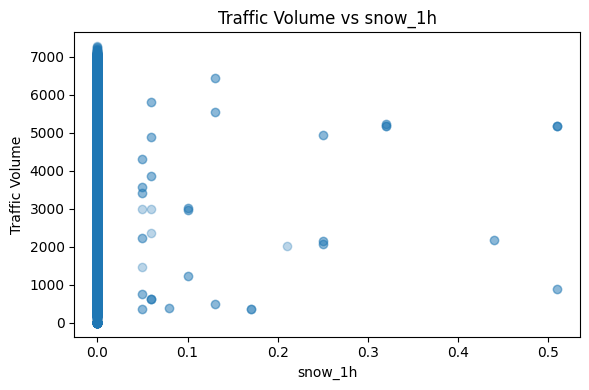

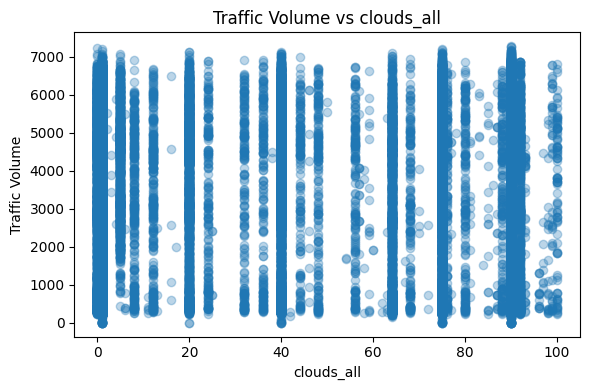

       traffic_volume        temp_f       rain_1h       snow_1h    clouds_all
count    48204.000000  48204.000000  48204.000000  48204.000000  48204.000000
mean      3259.818355     46.500826      0.334264      0.000222     49.362231
std       1986.860670     24.008685     44.789133      0.008168     39.015750
min          0.000000   -459.700000      0.000000      0.000000      0.000000
25%       1193.000000     30.200000      0.000000      0.000000      1.000000
50%       3380.000000     48.700000      0.000000      0.000000     64.000000
75%       4933.000000     65.600000      0.000000      0.000000     90.000000
max       7280.000000     98.500000   9831.300000      0.510000    100.000000
                traffic_volume  temp_f  rain_1h  snow_1h  clouds_all
traffic_volume           1.000   0.130    0.005    0.001       0.067
temp_f                   0.130   1.000    0.009   -0.020      -0.102
rain_1h                  0.005   0.009    1.000   -0.000       0.005
snow_1h               

In [18]:
numerical_weather = ["traffic_volume", "temp_f", "rain_1h", "snow_1h", "clouds_all"]
numerical_df = Metro[numerical_weather]

corr_matrix = numerical_df.corr().round(3)

for col in ["temp_f", "rain_1h", "snow_1h", "clouds_all"]:
    plt.figure(figsize=(6, 4))
    plt.scatter(numerical_df[col], numerical_df["traffic_volume"], alpha=0.3)
    plt.title(f"Traffic Volume vs {col}")
    plt.xlabel(col)
    plt.ylabel("Traffic Volume")
    plt.tight_layout()
    plt.show()

print(numerical_df.describe())
print (corr_matrix)

## Weather variables

| Variable | Raw issues | Correlation with volume | Visual cue |
|-----------|-----------|-------------------------|------------|
| **temp_f** | 10 rows read **0 K** (−459.7 °F) on 31 Jan and 2 Feb 2014. The Kelvin→°F conversion is correct; these are sensor/logging errors in the source file. | *r* ≈ 0.13 (weak positive) | Scatter is almost a vertical band except for the bad points at −460 °F. |
| **rain_1h** | 99 % zeros; one off-scale spike (9 831 mm on **11 Jul 2016 17:00**) | *r* ≈ 0.01 (none) | Point cloud sits at x = 0 with a single dot far right. |
| **snow_1h** | 100 % zeros except a few < 0.5 mm | *r* ≈ 0.00 | Only a handful of non-zero dots. |
| **clouds_all** | Discrete histogram spikes (0, 20, 40 … 100) | *r* ≈ 0.07 (tiny) | Dots fill the whole x-axis; no slope. |

The next cell drops the 0 K rows and the rain spike (11 rows in total).


In [19]:
filtered_Metro = Metro[(Metro['temp_f'] > -400) & (Metro['rain_1h'] < 100)].copy()
filtered_Metro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48193 entries, 0 to 48203
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     object        
 1   temp                 48193 non-null  float64       
 2   rain_1h              48193 non-null  float64       
 3   snow_1h              48193 non-null  float64       
 4   clouds_all           48193 non-null  int64         
 5   weather_main         48193 non-null  object        
 6   weather_description  48193 non-null  object        
 7   date_time            48193 non-null  datetime64[ns]
 8   traffic_volume       48193 non-null  int64         
 9   date                 48193 non-null  object        
 10  holiday_full_day     48193 non-null  object        
 11  hour                 48193 non-null  int32         
 12  month                48193 non-null  int32         
 13  year                 48193 non-null 

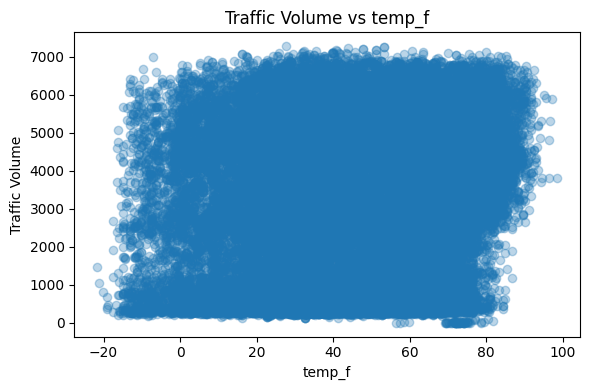

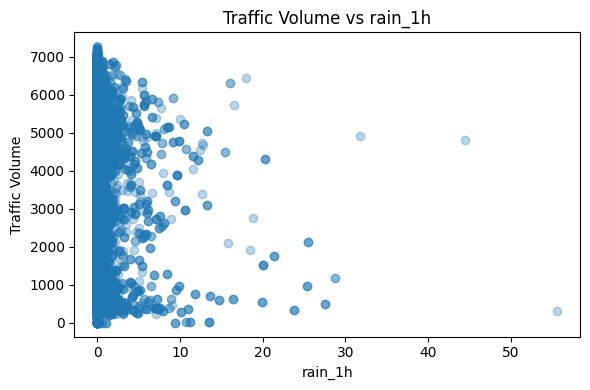

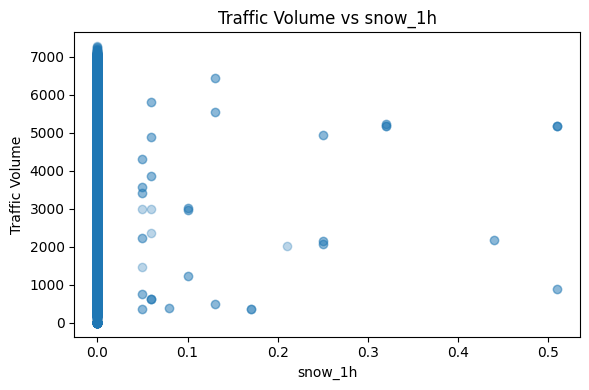

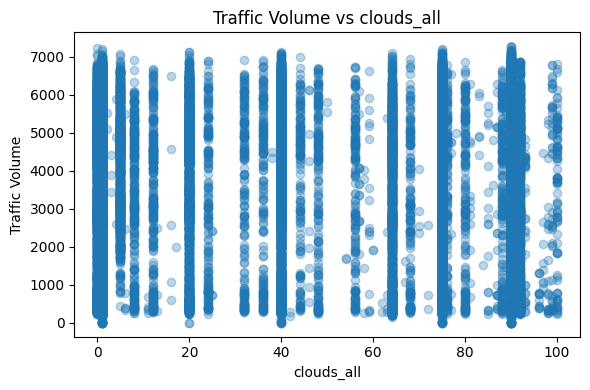

       traffic_volume        temp_f       rain_1h       snow_1h    clouds_all
count    48193.000000  48193.000000  48193.000000  48193.000000  48193.000000
mean      3260.174029     46.605082      0.130342      0.000222     49.371942
std       1986.754010     22.876578      1.003480      0.008169     39.013548
min          0.000000    -21.600000      0.000000      0.000000      0.000000
25%       1194.000000     30.300000      0.000000      0.000000      1.000000
50%       3380.000000     48.800000      0.000000      0.000000     64.000000
75%       4933.000000     65.600000      0.000000      0.000000     90.000000
max       7280.000000     98.500000     55.630000      0.510000    100.000000
                traffic_volume  temp_f  rain_1h  snow_1h  clouds_all
traffic_volume           1.000   0.132   -0.022    0.001       0.067
temp_f                   0.132   1.000    0.090   -0.021      -0.113
rain_1h                 -0.022   0.090    1.000    0.002       0.081
snow_1h               

In [20]:
numerical_weather = ["traffic_volume", "temp_f", "rain_1h", "snow_1h", "clouds_all"]
numerical_df = filtered_Metro[numerical_weather]

corr_matrix = numerical_df.corr().round(3)

for col in ["temp_f", "rain_1h", "snow_1h", "clouds_all"]:
    plt.figure(figsize=(6, 4))
    plt.scatter(numerical_df[col], numerical_df["traffic_volume"], alpha=0.3)
    plt.title(f"Traffic Volume vs {col}")
    plt.xlabel(col)
    plt.ylabel("Traffic Volume")
    plt.tight_layout()
    plt.show()

print(numerical_df.describe())
print (corr_matrix)

| Variable          | Typical Range (cleaned) | Correlation with Traffic | Notes                               |
|-------------------|-------------------------|--------------------------|---------------------------------------------|
| **Temp °F**       | −21.6 → 98.5            | *r* ≈ 0.13 (weak +)       | Warmer hours carry slightly more traffic, largely because summer daytime is busier; no threshold effect visible |
| **Rain 1 h (mm)** | 0 → 55.6                | *r* ≈ −0.02 (none)        | Rain rarely exceeds 10 mm; 99 % of hours are dry |
| **Snow 1 h (mm)** | 0 → 0.51                | *r* ≈ 0.00 (none)         | Ultra-sparse, winter-only |
| **Clouds_all %**  | 0 → 100                 | *r* ≈ 0.07 (weak +)       | Clusters at 0, 20, 40, 75, 90 % |

Removing the 11 bad rows changed the rain correlation sign (0.005 → −0.022) but left everything else essentially unchanged. None of the raw weather variables is a useful linear predictor on its own.


## Holidays

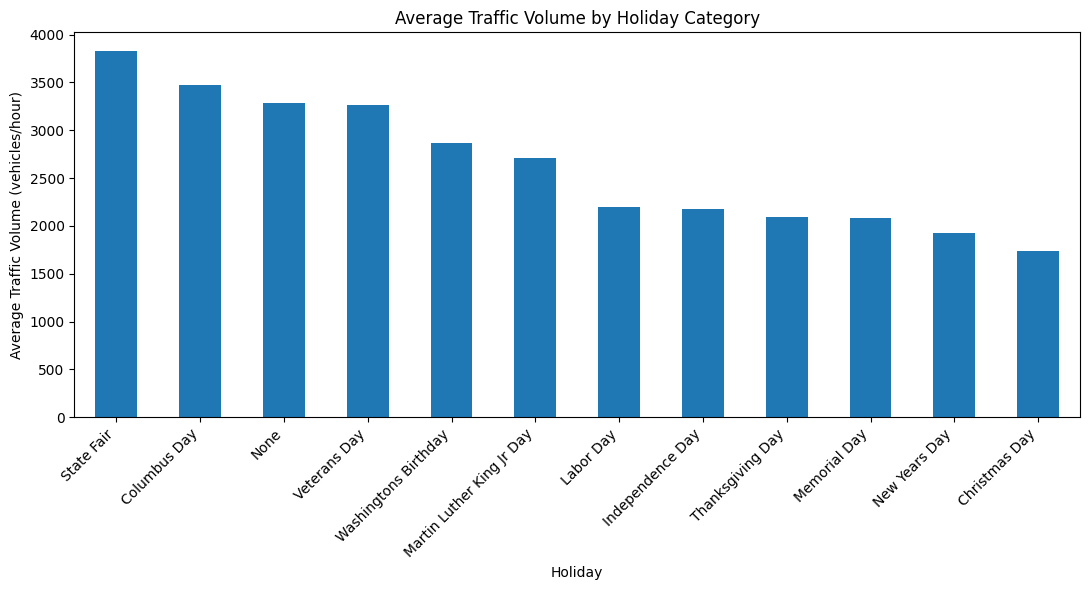

In [21]:
avg_by_holiday = (
    filtered_Metro.groupby("holiday_full_day")["traffic_volume"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))
avg_by_holiday.plot(kind="bar")
plt.title("Average Traffic Volume by Holiday Category")
plt.xlabel("Holiday")
plt.ylabel("Average Traffic Volume (vehicles/hour)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

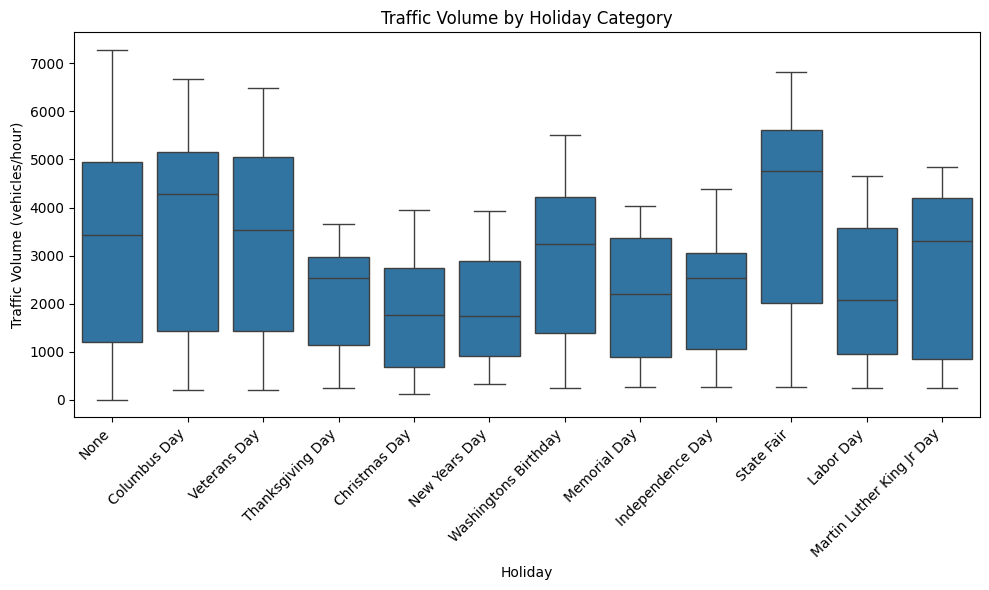

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="holiday_full_day", y="traffic_volume", data=filtered_Metro)
plt.title("Traffic Volume by Holiday Category")
plt.xlabel("Holiday")
plt.ylabel("Traffic Volume (vehicles/hour)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

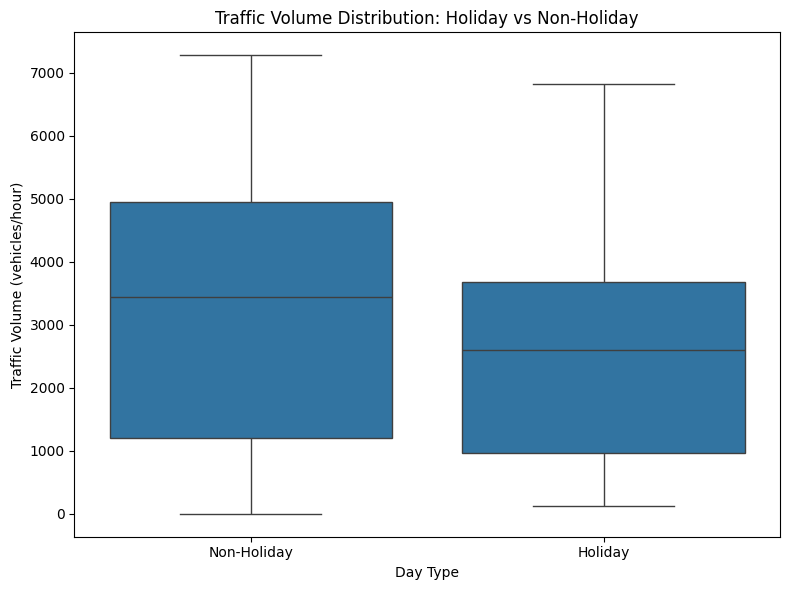

In [23]:
filtered_Metro['is_holiday'] = filtered_Metro['holiday_full_day'].apply(lambda x: 'Holiday' if x != 'None' else 'Non-Holiday')

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_holiday', y='traffic_volume', data=filtered_Metro)
plt.title("Traffic Volume Distribution: Holiday vs Non-Holiday")
plt.xlabel("Day Type")
plt.ylabel("Traffic Volume (vehicles/hour)")
plt.tight_layout()
plt.show()

In [24]:
avg_by_daytype = (
    filtered_Metro
    .groupby("is_holiday")["traffic_volume"]
    .mean()
    .rename({"Holiday": "avg_holiday", "Non-Holiday": "avg_nonholiday"})
)

diff_abs  = avg_by_daytype["avg_holiday"] - avg_by_daytype["avg_nonholiday"]
diff_pct  = diff_abs / avg_by_daytype["avg_nonholiday"] * 100

print(f"Average drop on holidays: {diff_abs:,.1f} vehicles/hour "
      f"({diff_pct:.1f}% lower than non-holidays)")

Average drop on holidays: -740.4 vehicles/hour (-22.6% lower than non-holidays)


In [25]:
holiday     = filtered_Metro.loc[filtered_Metro["is_holiday"] == "Holiday",      "traffic_volume"]
nonholiday  = filtered_Metro.loc[filtered_Metro["is_holiday"] == "Non-Holiday", "traffic_volume"]

n_H, n_NH   = len(holiday), len(nonholiday)
mean_H, mean_NH = holiday.mean(), nonholiday.mean()
var_H,  var_NH  = holiday.var(ddof=1), nonholiday.var(ddof=1)

t_stat, p_val = stats.ttest_ind(holiday, nonholiday, equal_var=False)

se_diff = np.sqrt(var_H / n_H + var_NH / n_NH)              # standard error
dof     = (var_H/n_H + var_NH/n_NH)**2 / (                 # Welch–Satterthwaite
           (var_H/n_H)**2 / (n_H-1) + (var_NH/n_NH)**2 / (n_NH-1))
crit    = stats.t.ppf(0.975, dof)                           # two-sided 95 %

diff    = mean_H - mean_NH
ci_low, ci_high = diff - crit*se_diff, diff + crit*se_diff

print(f"Mean difference (Holiday − Non-holiday): {diff:,.1f}")
print(f"95 % CI: [{ci_low:,.1f}, {ci_high:,.1f}]  (dof ≈ {dof:.1f})")
print(f"Welch t-test p-value: {p_val:.3g}")

Mean difference (Holiday − Non-holiday): -740.4
95 % CI: [-828.1, -652.7]  (dof ≈ 1535.4)
Welch t-test p-value: 9.07e-57


| Metric                               | Result                  | What it tells us                                                                                                                       |
| ------------------------------------ | ----------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Mean gap (Holiday – Non-holiday)** | **− 740 vehicles / hr** | Point-estimate: holidays see \~ 740 fewer vehicles each hour.                                                                          |
| **95 % confidence interval**         | **\[− 828, − 653]**     | Even the most conservative end (− 653) is well below 0, so the true population gap is very likely negative.                            |
| **Welch *t*-test p-value**           | **9 × 10⁻⁵⁷**           | Probability of observing such a large gap if there were actually no difference is essentially zero → result is statistically decisive. |

_Take-away_: the drop is both **statistically significant and practically large**—roughly a three-quarter-thousand-vehicle decline per hour, translating to a **22.6 % reduction** in mean traffic on holidays.

| Day type        | Typical level         | Spread & extremes                                | Interpretation                                                    |
| --------------- | --------------------- | ------------------------------------------------ | ----------------------------------------------------------------- |
| **Non-holiday** | Higher median traffic | Wider inter-quartile range and longer right tail | Rush-hour surges and occasional congestion spikes add variability |
| **Holiday**     | Lower median traffic  | Narrower IQR, virtually no extreme highs         | Commutes are lighter, and peak-hour congestion is largely absent  |

## Feature Engineering & Prediction Models

| Feature                                                               | Interpretation                                                           | Why it improves the model                                                                                             |
| --------------------------------------------------------------------- | ------------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------- |
| **Hour (sin, cos)**                                                   | Two smooth, cyclical coordinates derived from the raw hour.              | Removes the artificial jump from 23 → 0, giving linear models a continuous 24-hour circle.                            |
| **Day-of-week dummies** + **`is_weekend` flag**                       | Seven one-hot weekday columns plus a binary weekend indicator.           | Captures the strong weekday/weekend commuter pattern without assuming a linear order among days.                      |
| **Period-of-day bucket** (`morning`, `afternoon`, `evening`, `night`) | Categorical derived from `hour`.                                         | Lets tree-based models split directly on broad traffic regimes without 24 separate dummies.                           |
| **Rain / Snow flags** (`rain_flag`, `snow_flag`) & **`rain_heavy`**   | Binary “any precipitation” indicators and an extra flag for ≥ 5 mm rain. | Raw rainfall fields are 99 % zeros; flags isolate the rare—but impactful—wet hours that depress traffic.              |
| **Cloud bucket** (`low`, `mid`, `high`)                               | Three bins for sky cover (0–20 %, 20–80 %, 80–100 %).                    | Smooths noisy sensor plateaus (0, 20, 40, 75, 90 %) and retains only the broad visibility signal.                     |
| **Temperature bucket** (`freezing`, `cold`, `warm`, `hot`)            | Four comfort categories derived from °F.                                 | Traffic responds non-linearly at the extremes (icy roads or heat advisories); bins prevent an unhelpful linear slope. |

In [26]:
filtered_MetroV1 = filtered_Metro.copy()
filtered_Metro_Int = filtered_Metro.copy()

filtered_Metro_Int["hour_sin"] = np.sin(2 * np.pi * filtered_Metro["hour"] / 24)
filtered_Metro_Int["hour_cos"] = np.cos(2 * np.pi * filtered_Metro["hour"] / 24)

filtered_Metro_Int["day_name"]   = filtered_Metro["date_time"].dt.day_name()
filtered_Metro_Int["is_weekend"] = filtered_Metro["date_time"].dt.dayofweek.isin([5, 6]).astype(int)

def period_bucket(h):
    if 6 <= h < 12:
        return "morning"
    elif 12 <= h < 17:
        return "afternoon"
    elif 17 <= h < 21:
        return "evening"
    else:
        return "night"

filtered_Metro_Int["period"] = filtered_Metro_Int["hour"].apply(period_bucket)

filtered_Metro_Int["rain_flag"]    = (filtered_Metro_Int["rain_1h"]  > 0).astype(int)
filtered_Metro_Int["snow_flag"]    = (filtered_Metro_Int["snow_1h"]  > 0).astype(int)
filtered_Metro_Int["rain_heavy"]   = (filtered_Metro_Int["rain_1h"] >= 5).astype(int)

filtered_Metro_Int["cloud_bucket"] = pd.cut(
    filtered_Metro_Int["clouds_all"],
    bins=[-0.1, 20, 80, 100],
    labels=["low", "mid", "high"]
)

filtered_Metro_Int["temp_bucket"]  = pd.cut(
    filtered_Metro_Int["temp_f"],
    bins=[-20, 32, 60, 80, 120],
    labels=["freezing", "cold", "warm", "hot"]
)

cat_cols = ["period", "cloud_bucket", "temp_bucket", "day_name"]
filtered_Metro_Int = pd.get_dummies(filtered_Metro_Int, columns=cat_cols, drop_first=False)

numeric_cols = [
    "hour_sin", "hour_cos", "is_weekend",
    "rain_flag", "rain_heavy", "snow_flag"
]

one_hot_cols = [c for c in filtered_Metro_Int.columns
                if any(c.startswith(f"{col}_") for col in cat_cols)]

features = numeric_cols + one_hot_cols
target   = "traffic_volume"

In [27]:
test_start = pd.Timestamp("2017-09-01 00:00:00")
train_df = filtered_Metro_Int[filtered_Metro_Int["date_time"] < test_start].copy()
test_df = filtered_Metro_Int[filtered_Metro_Int["date_time"] >= test_start].copy()

train_df.to_csv("Metro_train_until_2017_08.csv", index=False)
test_df.to_csv("Metro_test_2017_09_to_2018_09.csv", index=False)

Simple Baseline Model

In [28]:
results = {}

# Baseline 1: hour-of-day mean
hourly_avg = train_df.groupby("hour")["traffic_volume"].mean()
overall_mean = train_df["traffic_volume"].mean()

test_eval = test_df.copy()
test_eval["y_pred"] = test_eval["hour"].map(hourly_avg).fillna(overall_mean)

mae  = mean_absolute_error(test_eval["traffic_volume"], test_eval["y_pred"])
rmse = root_mean_squared_error(test_eval["traffic_volume"], test_eval["y_pred"])
results["Baseline_hour_mean"] = (mae, rmse)

# Baseline 2: hour x day-of-week mean (a 168-cell lookup table)
hour_dow_avg = train_df.groupby(["hour", "dayofweek"])["traffic_volume"].mean()
keys = pd.Series(list(zip(test_eval["hour"], test_eval["dayofweek"])), index=test_eval.index)
test_eval["y_pred_dow"] = keys.map(hour_dow_avg).fillna(overall_mean)

mae_dow  = mean_absolute_error(test_eval["traffic_volume"], test_eval["y_pred_dow"])
rmse_dow = root_mean_squared_error(test_eval["traffic_volume"], test_eval["y_pred_dow"])
results["Baseline_hour_x_dow"] = (mae_dow, rmse_dow)

print("Train hourly means (veh/h):", hourly_avg.round(0).astype(int).to_dict())
print(pd.DataFrame([{"Model": k, "MAE": round(v[0], 2), "RMSE": round(v[1], 2)} for k, v in results.items()]))


Train hourly means (veh/h): {0: 837, 1: 521, 2: 393, 3: 371, 4: 695, 5: 2064, 6: 4154, 7: 4744, 8: 4603, 9: 4365, 10: 4172, 11: 4465, 12: 4716, 13: 4720, 14: 4943, 15: 5234, 16: 5645, 17: 5315, 18: 4267, 19: 3266, 20: 2827, 21: 2669, 22: 2196, 23: 1456}
                 Model     MAE    RMSE
0   Baseline_hour_mean  646.80  943.85
1  Baseline_hour_x_dow  300.27  529.23


### Baseline models

Two lookup-table baselines that need no learning algorithm at all. Every model that follows has to beat these to justify its complexity.

#### 1. Hour-of-day mean
For each hour label `0 … 23`, take the average training-set volume and predict it for every test row with that hour.
```text
hour 00 →  837 veh/h   # avg of all midnight rows in train_df
hour 01 →  521 veh/h
…
hour 16 → 5645 veh/h   # busiest hour
hour 17 → 5315 veh/h
```

#### 2. Hour × day-of-week mean
Same idea with a 168-cell table (24 hours × 7 days), so weekday and weekend profiles are kept apart.

| Baseline | test MAE | test RMSE |
|----------|---------:|----------:|
| Hour-of-day mean | 646.8 | 943.8 |
| Hour × day-of-week mean | **300.3** | **529.2** |

The second table alone already captures most of the predictable structure; a model that only matches it has learned nothing beyond the weekly clock.


In [29]:
X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])


Model Training

In [30]:
# Ridge
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = root_mean_squared_error(y_test, ridge_pred)
results["Ridge"] = (ridge_mae, ridge_rmse)

In [31]:
# Poisson
glm_model = PoissonRegressor(alpha=1e-4, max_iter=1000)
glm_model.fit(X_train_scaled, y_train)
glm_pred = glm_model.predict(X_test_scaled)
glm_mae  = mean_absolute_error(y_test, glm_pred)
glm_rmse = root_mean_squared_error(y_test, glm_pred)
results["Poisson_GLM"] = (glm_mae, glm_rmse)

C:\Users\Trigger\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Trigger\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\Trigger\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Trigger\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 969, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Trigger\AppData\Local\Programs\Python\Python31

In [32]:
#Random Forest
rf_model = RandomForestRegressor(
                               n_estimators=200,
                               max_depth=15,
                               n_jobs=-1,
                               random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
results["RandomForest"] = (rf_mae, rf_rmse)

In [33]:
metrics_df = pd.DataFrame([
    {"Model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    for name, (mae, rmse) in results.items()
]).sort_values("MAE")

print(metrics_df)

                 Model     MAE     RMSE
4         RandomForest  289.24   512.46
1  Baseline_hour_x_dow  300.27   529.23
0   Baseline_hour_mean  646.80   943.85
2                Ridge  779.36   974.10
3          Poisson_GLM  804.13  1007.90


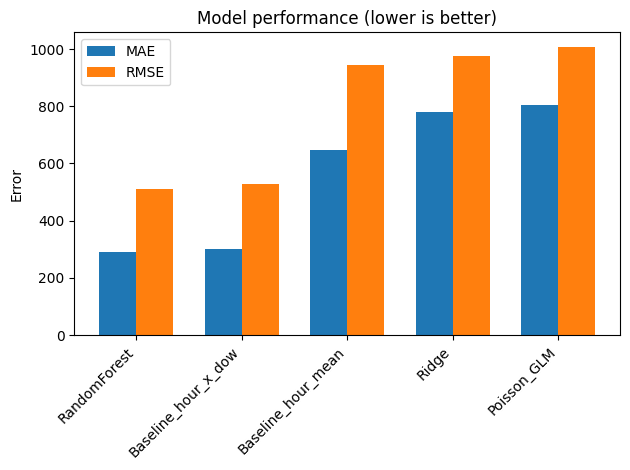

In [34]:
models = metrics_df["Model"].astype(str).values
mae_vals = metrics_df["MAE"].values
rmse_vals = metrics_df["RMSE"].values

x = np.arange(len(models))          
width = 0.35                       

fig, ax = plt.subplots()
ax.bar(x - width/2, mae_vals, width, label="MAE")
ax.bar(x + width/2, rmse_vals, width, label="RMSE")

ax.set_ylabel("Error")
ax.set_title("Model performance (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
fig.tight_layout()
plt.show()

### Initial Model Performance (V1 feature set)

| Model                    | MAE    | RMSE    |
| ------------------------ | -----: | ------: |
| RandomForest             | **289.24** | **512.46** |
| Baseline: hour × day-of-week | 300.27 | 529.23 |
| Baseline: hour mean      | 646.80 | 943.85  |
| Ridge                    | 779.36 | 974.10  |
| Poisson_GLM              | 804.13 | 1007.90 |

Two things stand out before any tuning:

* **Ridge and Poisson are worse than the trivial hour-of-day baseline.** With one-hot day names and a single sin/cos pair, a linear model cannot reproduce the two sharp commuter peaks, so it lands above 770 MAE.
* **The Random Forest beats the 168-cell lookup table by only about 11 vehicles per hour.** Most of what it learns is the weekly clock profile; weather adds very little.


In [35]:
def eval_fit(name, model, X_tr, y_tr, X_te, y_te, cv=None):
    """Return train/test MAE–RMSE plus an optional CV RMSE."""
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)

    tr_mae  = mean_absolute_error(y_tr, tr_pred)
    te_mae  = mean_absolute_error(y_te, te_pred)
    tr_rmse = root_mean_squared_error(y_tr, tr_pred)
    te_rmse = root_mean_squared_error(y_te, te_pred)

    cv_rmse = np.nan
    if cv is not None:
        cv_rmse = -cross_val_score(model, X_tr, y_tr,
                                   scoring="neg_root_mean_squared_error",
                                   cv=cv, n_jobs=-1).mean()
    return [tr_mae, te_mae, tr_rmse, te_rmse, cv_rmse]

tscv = TimeSeriesSplit(n_splits=5)  # pre

summary = pd.DataFrame(
    index=["Ridge", "Poisson_GLM", "RandomForest"],
    columns=["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "CV_RMSE"]
)

summary.loc["Ridge"]         = eval_fit("Ridge",         ridge_model, X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
summary.loc["Poisson_GLM"]   = eval_fit("Poisson_GLM",   glm_model,   X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
summary.loc["RandomForest"]  = eval_fit("RandomForest",  rf_model,    X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)

display(summary.astype(float).round(2))

,train_MAE,test_MAE,train_RMSE,test_RMSE,CV_RMSE
Ridge,780.05,779.36,978.05,974.10,984.76
Poisson_GLM,800.70,804.13,1010.76,1007.90,1028.53
RandomForest,265.96,289.24,466.88,512.46,527.17


| Model        | train\_MAE | test\_MAE | train\_RMSE | test\_RMSE | CV\_RMSE |
| ------------ | ---------- | --------- | ----------- | ---------- | -------- |
| Ridge        | 780.05     | 779.36    | 978.05      | 974.10     | 984.76   |
| Poisson\_GLM | 800.70     | 804.13    | 1010.76     | 1007.90    | 1028.53  |
| RandomForest | 265.96     | 289.24    | 466.88      | 512.46     | 527.17   |

`CV_RMSE` is a 5-fold `TimeSeriesSplit` on the training years, so each fold is scored on data that comes after its training window.

**Quick Takeaway**

- Random Forest is the clear winner on absolute error.
  - Test MAE 289 and RMSE 512: a **63 % lower MAE** and **47 % lower RMSE** than Ridge.
  - Train → test error rises by about 9 % (266 → 289 MAE) to 10 % (467 → 512 RMSE). Training error is optimistic by construction for a depth-15 forest, so the more useful generalisation check is CV RMSE (527) against test RMSE (512): they agree within 3 %.
  - The caveat is the baseline above: a lookup table gets 300 / 529. The forest's edge over "memorise the weekly profile" is thin.

- Ridge and Poisson GLM behave similarly.
  - Error around 780 MAE / 1 000 RMSE on train, test and CV alike.
  - Virtually no gap: they are well-regularised but too rigid to capture the nonlinear daily shape, and they lose to the hour-mean baseline.


### Interpreting the Random-Forest Feature-Importance Chart  

We observe that **time is by far the most important signal** in the model.
`period_night` holds the largest bar by a wide margin, far above the next non-time variable (`temp_bucket_freezing`).


* **Relative, not absolute** – the importances sum to 1. A bar twice as long as another means that feature reduced impurity roughly twice as much across all trees.  
* **Not causal** – a highly important feature is *useful* for prediction, but it isn’t necessarily the reason traffic behaves that way.

---

#### Time rules traffic volume  
* Knowing whether an observation occurs at **night** versus any other period explains the bulk of the variance.  
* Fine-grained **hour-of-day** information (captured by the `hour_sin` / `hour_cos` pair) refines the prediction next.  
* **Day-of-week** effects rank lower but still matter.

#### Weather is secondary  
The forest seldom relies on rain, cloud, or temperature buckets compared with temporal cues. That could mean:

1. Weather truly has only a small marginal effect in this dataset, **or**  
2. The strong temporal variables already explain most of the variation, leaving little incremental signal for weather to capture.

,feature,importance
0,period_night,0.666798
1,hour_sin,0.115086
2,hour_cos,0.093142
3,is_weekend,0.090247
4,period_afternoon,0.007913
5,day_name_Saturday,0.003658
6,temp_bucket_freezing,0.003626
7,day_name_Friday,0.002861
8,day_name_Monday,0.002788
9,day_name_Sunday,0.002041


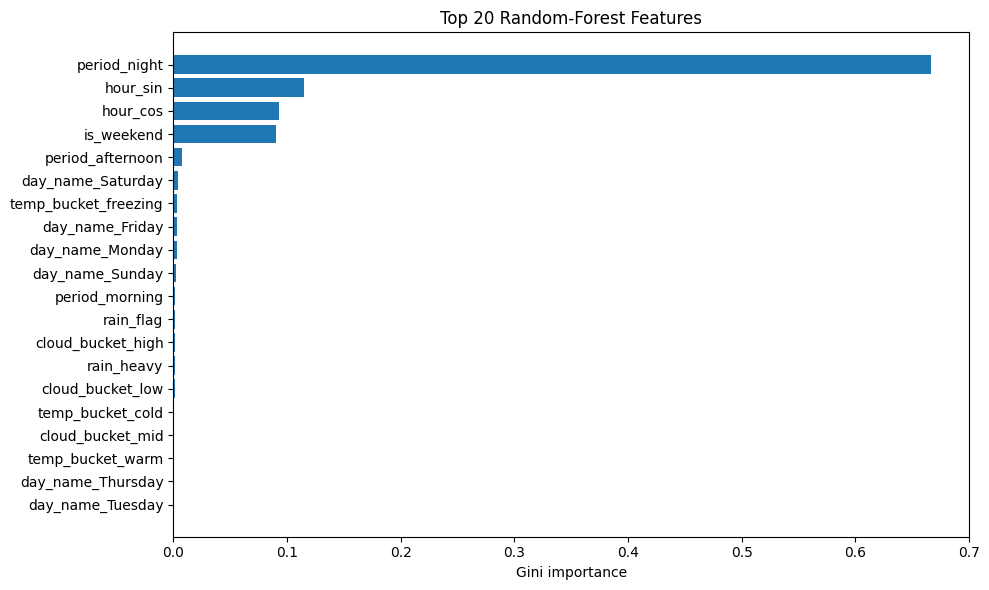

In [36]:
importances = rf_model.feature_importances_ 
feature_names = X_train.columns
top_idx = np.argsort(importances)[::-1][:20]
top_feats = pd.DataFrame({
    "feature": feature_names[top_idx],
    "importance": importances[top_idx]
})

display(top_feats)

plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"][::-1], top_feats["importance"][::-1])
plt.xlabel("Gini importance")
plt.title("Top 20 Random-Forest Features")
plt.tight_layout()
plt.show()

### What the importance plot tells us about V1

The V1 feature set contains the circular transforms `hour_sin` / `hour_cos`, a four-level `period` bucket, day-of-week dummies, a weekend flag, and coarse weather buckets. Raw `hour` is **not** a model input.

In the Gini-importance plot `period_night` alone accounts for **0.67** of total importance, the sin/cos pair for another 0.21, and `is_weekend` for 0.09. Every weather feature is below 0.004.

Two conclusions:
- The forest is mostly encoding "night = low, weekend = lower, otherwise follow the clock". That is exactly what the hour × day-of-week lookup table does, which is why the two score almost the same.
- Gini importance is split-frequency weighted, so a binary feature that separates the largest chunk of variance (night vs. day) will dominate even when finer features do the remaining work. The number should not be read as "weather does not matter", only as "weather does not matter *after* time is known".


In [37]:
filtered_Metro_V2 = filtered_Metro.copy()

filtered_Metro_V2["hour_sin"] = np.sin(2 * np.pi * filtered_Metro_V2["hour"] / 24)
filtered_Metro_V2["hour_cos"] = np.cos(2 * np.pi * filtered_Metro_V2["hour"] / 24)

filtered_Metro_V2["day_name"]   = filtered_Metro_V2["date_time"].dt.day_name()
filtered_Metro_V2["is_weekend"] = (filtered_Metro_V2["date_time"].dt.dayofweek >= 5).astype(int)

def period_bucket(h: int) -> str:
    if h >= 21 or h < 6:
        return "night"
    elif 6 <= h < 8 or 18 <= h < 21:
        return "shoulder"
    else:                           
        return "rush_core"

filtered_Metro_V2["period"] = filtered_Metro_V2["hour"].apply(period_bucket)

filtered_Metro_V2["rain_flag"]  = (filtered_Metro_V2["rain_1h"]  > 0).astype(int)
filtered_Metro_V2["snow_flag"]  = (filtered_Metro_V2["snow_1h"]  > 0).astype(int)
filtered_Metro_V2["rain_heavy"] = (filtered_Metro_V2["rain_1h"] >= 5).astype(int)

filtered_Metro_V2["cloud_bucket"] = pd.cut(
    filtered_Metro_V2["clouds_all"],
    bins=[-0.1, 20, 80, 100],
    labels=["low", "mid", "high"],
    ordered=True
)

filtered_Metro_V2["temp_bucket"] = pd.cut(
    filtered_Metro_V2["temp_f"],
    bins=[-20, 32, 60, 80, 120],
    labels=["freezing", "cold", "warm", "hot"],
    ordered=True
)

filtered_Metro_V2["sin_rain"]      = filtered_Metro_V2["hour_sin"] * filtered_Metro_V2["rain_flag"]
filtered_Metro_V2["cos_rain"]      = filtered_Metro_V2["hour_cos"] * filtered_Metro_V2["rain_flag"]
filtered_Metro_V2["sin_snow"]      = filtered_Metro_V2["hour_sin"] * filtered_Metro_V2["snow_flag"]
filtered_Metro_V2["cos_snow"]      = filtered_Metro_V2["hour_cos"] * filtered_Metro_V2["snow_flag"]
filtered_Metro_V2["sin_weekend"]   = filtered_Metro_V2["hour_sin"] * filtered_Metro_V2["is_weekend"]
filtered_Metro_V2["cos_weekend"]   = filtered_Metro_V2["hour_cos"] * filtered_Metro_V2["is_weekend"]

filtered_Metro_V2["period_day"] = (
    filtered_Metro_V2["period"] + "_" + filtered_Metro_V2["day_name"]
)

filtered_Metro_V2["period_temp"] = (
    filtered_Metro_V2["period"] + "_" + filtered_Metro_V2["temp_bucket"].astype(str)
)

filtered_Metro_V2["period_rain"] = (
    filtered_Metro_V2["period"] + "_" +
    np.where(filtered_Metro_V2["rain_flag"], "rain", "dry")
)

filtered_Metro_V2["period_snow"] = (
    filtered_Metro_V2["period"] + "_" +
    np.where(filtered_Metro_V2["snow_flag"], "snow", "nosnow")
)

filtered_Metro_V2["period_weekend"] = (
    filtered_Metro_V2["period"] + "_" +
    np.where(filtered_Metro_V2["is_weekend"], "weekend", "weekday")
)

filtered_Metro_V2.drop(columns=["period"], inplace=True)

base_cat_cols = [
    "day_name", "cloud_bucket", "temp_bucket",
    "period_day", "period_temp",
    "period_rain", "period_snow", "period_weekend",
]

filtered_Metro_V2 = pd.get_dummies(
    filtered_Metro_V2,
    columns=base_cat_cols,
    drop_first=False,
    dtype=float
)

numeric_cols = [
    "hour_sin", "hour_cos",
    "is_weekend", "rain_flag", "rain_heavy", "snow_flag",
    "sin_rain", "cos_rain", "sin_snow", "cos_snow", "sin_weekend", "cos_weekend",
]

one_hot_cols = [
    col for col in filtered_Metro_V2.columns
    if any(col.startswith(prefix + "_") for prefix in
           ["day_name", "cloud_bucket", "temp_bucket",
            "period_day", "period_temp",
            "period_rain", "period_snow", "period_weekend",])
]

features = numeric_cols + one_hot_cols
target   = "traffic_volume"

test_start = pd.Timestamp("2017-09-01 00:00:00")

train_df = filtered_Metro_V2[filtered_Metro_V2["date_time"] <  test_start].copy()
test_df  = filtered_Metro_V2[filtered_Metro_V2["date_time"] >= test_start].copy()
train_df.to_csv("Metro_train_V2_until_2017_08.csv", index=False)
test_df.to_csv("Metro_test_V2_2017_09_to_2018_09.csv",  index=False)

### Moving to Version 2: composite period-weather categories

V1 leaned almost entirely on `period_night` (Gini importance 0.67). To give the trees richer, less redundant splits we:

**1. Replaced** the four-level `period` bucket with a three-level one (`night`, `shoulder`, `rush_core`) and **dropped the raw `period` column** after using it to build composites.
**2. Kept** `hour_sin` / `hour_cos`, so the model still sees the continuous 24-hour clock. (An earlier draft dropped them; that removed all hour information on dry weekdays and doubled the error, so they are back.)
**3. Introduced** hour × condition interactions (`sin_rain`, `cos_rain`, `sin_snow`, `cos_snow`, `sin_weekend`, `cos_weekend`).
**4. Introduced** five composite categoricals that join the period bucket with another factor: `period_day`, `period_temp`, `period_rain`, `period_snow`, `period_weekend`.

```python
filtered_Metro_V2["period_day"]     = period + "_" + day_name
filtered_Metro_V2["period_temp"]    = period + "_" + temp_bucket
filtered_Metro_V2["period_rain"]    = period + "_" + ("rain" | "dry")
filtered_Metro_V2["period_snow"]    = period + "_" + ("snow" | "nosnow")
filtered_Metro_V2["period_weekend"] = period + "_" + ("weekend" | "weekday")
filtered_Metro_V2.drop(columns=["period"], inplace=True)
```

Note that **no holiday feature is used in any model version**; holidays are analysed in the EDA only.


In [38]:
X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

In [39]:
resultsV2 = {}

ridge_v2 = Ridge(alpha=1.0, random_state=42).fit(X_train_scaled, y_train)
glm_v2   = PoissonRegressor(alpha=1e-4, max_iter=1000).fit(X_train_scaled, y_train)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train_scaled, y_train)

for name, mdl in [("Ridge", ridge_v2), ("Poisson_GLM", glm_v2), ("RandomForest", rf_model)]:
    pred = mdl.predict(X_test_scaled)
    resultsV2[name] = (mean_absolute_error(y_test, pred), root_mean_squared_error(y_test, pred))
    print(f"{name:13s} MAE: {resultsV2[name][0]:.2f}   RMSE: {resultsV2[name][1]:.2f}")


Ridge         MAE: 705.65   RMSE: 877.89
Poisson_GLM   MAE: 782.80   RMSE: 946.85
RandomForest  MAE: 287.95   RMSE: 510.64


### What changed?

| Model | V1 test MAE | V2 test MAE | V1 test RMSE | V2 test RMSE |
| ----- | ----------: | ----------: | -----------: | -----------: |
| Ridge        | 779.36 | **705.65** | 974.10  | **877.89** |
| Poisson_GLM  | 804.13 | **782.80** | 1007.90 | **946.85** |
| RandomForest | 289.24 | **287.95** | 512.46  | **510.64** |

* **The linear models gained the most** (Ridge −9 % MAE). The hour × rain / hour × weekend interaction terms give a linear model a way to bend the daily curve differently on weekends and wet hours.
* **The forest barely moved** (−1.3 MAE). Trees can already build such interactions from the raw columns, so the composites mostly re-label splits it was making anyway.
* Nothing regressed. An earlier draft of V2 dropped `hour_sin` / `hour_cos` as well; that version lost all hour information on dry weekdays and its forest MAE jumped to about 656. Keeping the clock features is what makes V2 a fair test.


In [40]:
summaryV2 = pd.DataFrame(
    index=["Ridge", "Poisson_GLM", "RandomForest"],
    columns=["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "CV_RMSE"]
)
summaryV2.loc["Ridge"]        = eval_fit("Ridge",        ridge_v2, X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
summaryV2.loc["Poisson_GLM"]  = eval_fit("Poisson_GLM",  glm_v2,   X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
summaryV2.loc["RandomForest"] = eval_fit("RandomForest", rf_model, X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
display(summaryV2.astype(float).round(2))


,train_MAE,test_MAE,train_RMSE,test_RMSE,CV_RMSE
Ridge,696.86,705.65,874.88,877.89,888.29
Poisson_GLM,772.62,782.80,939.71,946.85,957.18
RandomForest,267.08,287.95,468.86,510.64,528.47


### Key take-aways from V2

* Composite categories help models that cannot build interactions themselves; they are close to neutral for tree ensembles.
* Always compare **train vs CV** (or a temporal **hold-out**) error; a low training error alone is not evidence of anything.
* The next step is a **stacked ensemble** (Random Forest + XGBoost with a Ridge meta-learner) to see whether blending two tree learners buys anything on this feature set.

### V2 cross-validation results (all models)

| Model            | train\_MAE | test\_MAE | train\_RMSE | test\_RMSE | CV\_RMSE |
| ---------------- | ---------- | --------- | ----------- | ---------- | -------- |
| **Ridge**        | 696.86     | 705.65    | 874.88      | 877.89     | 888.29   |
| **Poisson\_GLM** | 772.62     | 782.80    | 939.71      | 946.85     | 957.18   |
| **RandomForest** | 267.08     | 287.95    | 468.86      | 510.64     | 528.47   |
| Baseline: hour × day-of-week (V1 split) | – | 300.27 | – | 529.23 | – |

**Interpretation**
The forest still wins on absolute accuracy. Train → test gaps are about 1 % for the linear models and 8–9 % for the forest; CV RMSE tracks test RMSE within 4 % for all three, so the hold-out year behaves like the training years. The linear models closed part of the gap, but they remain far behind the lookup-table baseline.


In [41]:
#ensamble method
from xgboost import XGBRegressor                        
rf_clf = RandomForestRegressor(
    n_estimators      = 300, 
    max_depth         = 12,      
    min_samples_leaf  = 5,      
    n_jobs            = -1,
    random_state      = 42,
)

xgb_clf = XGBRegressor(          
    n_estimators      = 600,     
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    objective        ='reg:squarederror',
    reg_lambda        = 1.0,
    n_jobs            = -1,
    random_state      = 42,
)

base_estimators = [
    ("rf",  rf_clf),
    ("xgb", xgb_clf),                                      
]

meta_learner = RidgeCV(alphas=np.logspace(-6, 6, 13))
kf = KFold(n_splits=5, shuffle=False)

stack_model = StackingRegressor(
    estimators      = base_estimators,
    final_estimator = meta_learner,
    passthrough     = True,
    cv              = kf,
    n_jobs          = -1,
)

stack_model.fit(X_train_scaled, y_train)
stack_pred = stack_model.predict(X_test_scaled)

stack_mae = mean_absolute_error(y_test, stack_pred)
stack_rmse = root_mean_squared_error(y_test, stack_pred)

print(f"Stacked MAE : {stack_mae:,.2f}")
print(f"Stacked RMSE: {stack_rmse:,.2f}")

Stacked MAE : 282.86
Stacked RMSE: 502.86


In [42]:
summaryV3 = pd.DataFrame(
    index=["Stacked"],
    columns=["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "CV_RMSE"]
)
summaryV3.loc["Stacked"]  = eval_fit("Stacked",  stack_model,    X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
display(summaryV3.astype(float).round(2))

,train_MAE,test_MAE,train_RMSE,test_RMSE,CV_RMSE
Stacked,275.22,282.86,480.08,502.86,513.82


### Rationale for an Ensemble
* **Blend different inductive biases.**
  * **Random Forest (RF)** averages many deep, decorrelated trees: low variance, good at sharp regime changes.
  * **XGBoost (XGB)** fits shallow trees to residuals sequentially: lower bias on structured tabular data.
* **Linear stabiliser on top.** A level-1 `RidgeCV` is trained on the out-of-fold RF and XGB predictions plus the original features (`passthrough=True`). It learns how much to trust each base learner rather than hand-picking weights.

**Stack (V2 features)**
1. Base learners: Random Forest (300 trees, depth 12) and XGBoost (600 rounds, depth 4, learning-rate 0.05).
2. Meta-learner: `RidgeCV` over the two base predictions and the raw features.
3. Out-of-fold predictions come from an unshuffled 5-fold `KFold`, because `StackingRegressor` needs every training row to appear in exactly one validation fold and `TimeSeriesSplit` does not satisfy that. **This is a genuine weakness**: the out-of-fold predictions for the first block (Oct 2012 – mid 2013) come from base models trained entirely on later years, and every block except the last is predicted by models that have seen its future. The meta-learner is therefore fitted on predictions that are more accurate than any it could have had in real time, which can make it over-trust the base learners. The hold-out year (Sep 2017 – Sep 2018) is still strictly after all training data, so the **test** scores are not contaminated; only the way the two base learners are weighted is. Version 5 replaces this with a time-aware stacker.

### Stacked Model Performance (V2)

| Model                     | train\_MAE | test\_MAE | train\_RMSE | test\_RMSE | CV\_RMSE |
| ------------------------- | ---------- | --------- | ----------- | ---------- | -------- |
| **Stacked (RF + XGB → Ridge)** | 275.22 | **282.86** | 480.08 | **502.86** | 513.82 |
| RandomForest alone (V2)   | 267.08     | 287.95    | 468.86      | 510.64     | 528.47   |

The stack shaves about 5 MAE / 8 RMSE off the lone forest, a **1.8 % improvement**. It is a real but small gain: both base learners see the same calendar features, so they make correlated mistakes. Without information about what traffic actually did recently, no amount of ensembling will close the remaining gap.


In [43]:
# Version 3: lagged volumes aligned by TIMESTAMP, not by row position.
# The raw file has duplicate timestamps (one row per weather description) and
# missing hours, so `shift(n)` does not mean "n hours earlier". We de-duplicate
# on date_time first, then look each lag up by (timestamp - n hours).
filtered_Metro_V3 = (
    filtered_Metro_V2.sort_values("date_time")
    .drop_duplicates(subset="date_time", keep="first")
    .reset_index(drop=True)
)
print(f"Rows before de-duplication: {len(filtered_Metro_V2):,}   after: {len(filtered_Metro_V3):,}")

vol_by_ts = filtered_Metro_V3.set_index("date_time")["traffic_volume"]
lags = [1, 24, 168]                       # 1 hour, 1 day, 1 week
for lag in lags:
    filtered_Metro_V3[f"vol_lag_{lag}h"] = (
        (filtered_Metro_V3["date_time"] - pd.Timedelta(hours=lag)).map(vol_by_ts).values
    )

lag_cols = [f"vol_lag_{lag}h" for lag in lags]
n_before = len(filtered_Metro_V3)
filtered_Metro_V3.dropna(subset=lag_cols, inplace=True)
filtered_Metro_V3.reset_index(drop=True, inplace=True)
print(f"Rows dropped because a lag hour is absent from the sensor record: {n_before - len(filtered_Metro_V3):,}")

features = numeric_cols + one_hot_cols + lag_cols
target   = "traffic_volume"

test_start = pd.Timestamp("2017-09-01 00:00:00")
train_df = filtered_Metro_V3[filtered_Metro_V3["date_time"] <  test_start].copy()
test_df  = filtered_Metro_V3[filtered_Metro_V3["date_time"] >= test_start].copy()
print(f"train rows: {len(train_df):,}   test rows: {len(test_df):,}")

train_df.to_csv("Metro_train_V3_until_2017_08.csv", index=False)
test_df.to_csv("Metro_test_V3_2017_09_to_2018_09.csv",  index=False)

# Persistence baselines: predict this hour = the lagged hour, no model at all
persistence = {}
for lag in lags:
    p = test_df[f"vol_lag_{lag}h"]
    persistence[f"Persistence_{lag}h"] = (
        mean_absolute_error(test_df[target], p), root_mean_squared_error(test_df[target], p)
    )
print(pd.DataFrame([{"Baseline": k, "MAE": round(v[0], 2), "RMSE": round(v[1], 2)} for k, v in persistence.items()]))


Rows before de-duplication: 48,193   after: 40,564
Rows dropped because a lag hour is absent from the sensor record: 5,867
train rows: 25,325   test rows: 9,372


           Baseline     MAE     RMSE
0    Persistence_1h  591.77   819.90
1   Persistence_24h  567.57  1027.22
2  Persistence_168h  340.47   655.24


### Version 3 - Lagged Traffic-Volume Features
**Introduced** three autoregressive predictors, `vol_lag_1h`, `vol_lag_24h` and `vol_lag_168h`: the volume recorded exactly 1 hour, 1 day and 1 week earlier.

Two data-quality steps are essential here:

* **De-duplicate timestamps.** The raw file has 7 629 duplicate `date_time` rows (one row per weather description for the same hour, all with the same volume). A positional `shift(1)` on that frame would return the *same hour's* volume 16 % of the time, i.e. it would hand the model the target.
* **Look lags up by timestamp, not by row.** About 4 400 hours are missing from the record (including a 10-month gap in 2014–15). Shifting rows across those gaps produced "24-hour" lags that were actually 24 hours old only a third of the time, and "1-week" lags that were correct only 6 % of the time.

The 720-hour (30-day) lag from the earlier draft was dropped: after proper alignment it was available for far fewer rows and adds little beyond the weekly lag.

| New feature    | Captures                                     | Why it helps                                                                                                                    |
| -------------- | -------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| `vol_lag_1h`   | Short-term momentum (e.g., congestion waves) | Traffic rarely spikes or dissipates instantaneously; the previous hour is the strongest single predictor of the next one. **Only usable for a 1-hour-ahead forecast.** |
| `vol_lag_24h`  | Daily seasonality                            | Weekday commuter peaks repeat almost perfectly day-to-day at the same clock hour. Available 24 h before the target hour.        |
| `vol_lag_168h` | Weekly seasonality                           | Mondays resemble the previous Monday more than the previous day; this lag encodes that weekly rhythm.                           |

Because the lags require a de-duplicated, gap-free window, the V3 train/test sets are smaller than V1/V2 (row counts are printed above). The `RF_calendar_and_weather_no_lags` reference in Version 4 re-fits the V2 feature set on exactly these rows so the comparison is like-for-like.


Cyclical encodings (`hour_sin, day_name, etc.`) tell the model when we are in the calendar. Lagged volumes tell it what actually happened last time at this moment. Combining both lets the learner capture systematic patterns and transient deviations

In [44]:
X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

In [45]:
#ensamble method
from xgboost import XGBRegressor                        
rf_clf = RandomForestRegressor(
    n_estimators      = 300,     
    max_depth         = 12,      
    min_samples_leaf  = 5,       
    n_jobs            = -1,
    random_state      = 42,
)

xgb_clf = XGBRegressor(                                   
    n_estimators      = 600,     
    learning_rate     = 0.05,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    objective        ='reg:squarederror',
    reg_lambda        = 1.0,
    n_jobs            = -1,
    random_state      = 42,
)

base_estimators = [
    ("rf",  rf_clf),
    ("xgb", xgb_clf),
]

meta_learner = RidgeCV(alphas=np.logspace(-6, 6, 13))
kf = KFold(n_splits=5, shuffle=False)

stack_model = StackingRegressor(
    estimators      = base_estimators,
    final_estimator = meta_learner,
    passthrough     = True,
    cv              = kf,
    n_jobs          = -1,
)

stack_model.fit(X_train_scaled, y_train)
stack_pred = stack_model.predict(X_test_scaled)

stack_mae = mean_absolute_error(y_test, stack_pred)
stack_rmse = root_mean_squared_error(y_test, stack_pred)

print(f"Stacked MAE : {stack_mae:,.2f}")
print(f"Stacked RMSE: {stack_rmse:,.2f}")

Stacked MAE : 151.35
Stacked RMSE: 235.54


In [46]:
summaryV3 = pd.DataFrame(
    index=["Stacked"],
    columns=["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "CV_RMSE"]
)
summaryV3.loc["Stacked"]  = eval_fit("Stacked",  stack_model,    X_train_scaled, y_train, X_test_scaled, y_test, cv=tscv)
display(summaryV3.astype(float).round(2))

,train_MAE,test_MAE,train_RMSE,test_RMSE,CV_RMSE
Stacked,139.08,151.35,217.39,235.54,258.77


In [47]:
ridge = stack_model.final_estimator_
# With passthrough=True the meta Ridge has one coefficient per base learner
# followed by one per raw feature; only the first two are stacking weights.
meta_weights = dict(zip([name for name, _ in base_estimators], ridge.coef_[:len(base_estimators)]))
print("Meta weights:", {k: round(float(v), 3) for k, v in meta_weights.items()})
print("Intercept   :", round(float(ridge.intercept_), 3))
print("Passthrough coefficients (count):", len(ridge.coef_) - len(base_estimators))


Meta weights: {'rf': 0.174, 'xgb': 0.867}
Intercept   : -1.123
Passthrough coefficients (count): 82


## Performance jump from **V2** to **V3** (1-hour-ahead horizon)

| Metric | V2 Stacked | V3 Stacked | Δ (absolute) | Δ (relative) |
|--------|-----------:|-----------:|-------------:|-------------:|
| **MAE — train** | 275.22 | **139.08** | −136.14 | **−49.5 %** |
| **MAE — test**  | 282.86 | **151.35** | −131.51 | **−46.5 %** |
| **RMSE — train**| 480.08 | **217.39** | −262.69 | **−54.7 %** |
| **RMSE — test** | 502.86 | **235.54** | −267.32 | **−53.2 %** |
| **RMSE — CV**   | 513.82 | **258.77** | −255.05 | **−49.6 %** |

The V3 rows are scored on the de-duplicated test set (9 372 rows) whereas V2 used all 11 407 rows; the like-for-like "no lags, same rows" reference in Version 4 below confirms that the gain is not an artefact of the row change.

### Against the persistence baselines

| Predictor for hour *t* | test MAE | test RMSE |
|------------------------|---------:|----------:|
| volume at *t* − 1 h (persistence)   | 591.77 | 819.90 |
| volume at *t* − 24 h (persistence)  | 567.57 | 1027.22 |
| volume at *t* − 168 h (persistence) | 340.47 | 655.24 |
| **V3 stacked model**                | **151.35** | **235.54** |

Simply repeating last hour's count is a poor forecast (traffic ramps by thousands of vehicles within an hour at 05:00–07:00). Repeating last week's same hour is much better than repeating yesterday's, which confirms the weekly rhythm. The model beats the best persistence rule by more than half.

### Interpretation

* **Large, genuine gain.** Train, CV and test errors all fell by roughly the same proportion. The train → test gap is about 9 % (139 → 151 MAE, 217 → 236 RMSE) and CV RMSE (259) is 10 % above test RMSE (236), so the hold-out year is, if anything, slightly easier than the CV folds. This is added signal, not a tighter fit to the training years.
* **Meta-learner weights.** The Ridge super-learner puts 0.87 on XGBoost and 0.17 on the Random Forest. Note that with `passthrough=True` the meta-learner also carries 82 raw-feature coefficients, so these two numbers are not a complete description of the blend.
* **Read the horizon carefully.** `vol_lag_1h` means the forecast for 08:00 is made with the 07:00 count already in hand. That is a *one-hour-ahead nowcast*, which is what a live variable-message-sign or ramp-metering system needs, but it is not the same task as V1/V2, which used no traffic history at all. Version 4 removes the 1-hour lag to give a 24-hour-ahead figure. Both versions also use the **observed** weather at the target hour; Version 5 addresses that.


### Version 4 - Rolling 24-hour-ahead horizon (no 1-hour lag)

Operational planning (staffing, lane closures, incident response) happens well before the hour being planned for, when the previous hour's count does not exist yet. V4 keeps the same feature set and the same stack but drops `vol_lag_1h`, leaving the 24-hour and 168-hour lags.

**What this evaluation is, precisely.** Every test hour is predicted using *its own* 24-hour and 168-hour lags: the 09:00 prediction uses yesterday's 09:00, the 10:00 prediction uses yesterday's 10:00, and so on. That is a **rolling 24-hour-ahead** evaluation, in which the forecast for each hour is issued exactly 24 hours before it.

**What it is not.** It is not a next-day forecast issued once at a fixed planning time. A dispatcher who runs the model at 17:00 on Monday to plan all of Tuesday has lags of 7 to 31 hours old depending on the target hour, and for the late-Tuesday hours the required 24-hour lag has not been observed yet. Such a model would either have to recurse on its own predictions or use only lags of 24 hours or more relative to the *issue* time. Both are more demanding than what is measured here, so **the figures below are an optimistic bound on fixed-issue-time next-day performance**, not a measurement of it.

The same cell also refits the Random Forest with **no lags at all** on exactly the same de-duplicated rows, so the value of the lags can be read off directly. That reference still contains the V2 weather features, so it is labelled `RF_calendar_and_weather_no_lags`; a genuinely calendar-only reference (no weather either) is fitted in Version 5.


In [48]:
# Same stack, but without vol_lag_1h: each hour predicted from its own 24 h and 168 h lags
# (a rolling 24-hour-ahead evaluation - see the note above on what this does and does not show).
from sklearn.base import clone
from sklearn.metrics import r2_score

features_v4 = numeric_cols + one_hot_cols + ["vol_lag_24h", "vol_lag_168h"]
X_train_v4, X_test_v4 = X_train_scaled[features_v4], X_test_scaled[features_v4]

stack_v4 = clone(stack_model).fit(X_train_v4, y_train)
stack_pred_v4 = stack_v4.predict(X_test_v4)

# Reference: same RF on the V2 feature set (calendar AND weather), no lags, same de-duplicated rows
nolag_cols = numeric_cols + one_hot_cols
rf_nolag = clone(rf_clf).fit(X_train_scaled[nolag_cols], y_train)

summaryV4 = pd.DataFrame(columns=["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "CV_RMSE"])
summaryV4.loc["Stacked_V4_24h_ahead"] = eval_fit("Stacked_V4", stack_v4, X_train_v4, y_train, X_test_v4, y_test, cv=tscv)
summaryV4.loc["RF_calendar_and_weather_no_lags"] = eval_fit("RF_nolag", rf_nolag, X_train_scaled[nolag_cols], y_train,
                                                            X_test_scaled[nolag_cols], y_test, cv=tscv)
display(summaryV4.astype(float).round(2))

r2_v4 = r2_score(y_test, stack_pred_v4)
print(f"V4 rolling 24 h-ahead  MAE: {summaryV4.loc['Stacked_V4_24h_ahead','test_MAE']:.2f}  "
      f"RMSE: {summaryV4.loc['Stacked_V4_24h_ahead','test_RMSE']:.2f}  R2: {r2_v4:.3f}")


,train_MAE,test_MAE,train_RMSE,test_RMSE,CV_RMSE
Stacked_V4_24h_ahead,226.86,250.06,390.07,456.71,457.81
RF_calendar_and_weather_no_lags,276.54,277.77,479.75,481.24,501.91


V4 rolling 24 h-ahead  MAE: 250.06  RMSE: 456.71  R2: 0.947


### V4 results

| Model (same de-duplicated rows) | train\_MAE | test\_MAE | train\_RMSE | test\_RMSE | CV\_RMSE | test R² |
| ------------------------------- | ---------: | --------: | ----------: | ---------: | -------: | ------: |
| **Stacked, rolling 24 h ahead (24 h + 168 h lags)** | 226.86 | **250.06** | 390.07 | **456.71** | 457.81 | **0.947** |
| RandomForest, no lags (V2 calendar **and weather** features) | 276.54 | 277.77 | 479.75 | 481.24 | 501.91 | – |
| Stacked, 1-hour-ahead (V3, for reference) | 139.08 | 151.35 | 217.39 | 235.54 | 258.77 | 0.986 |
| Persistence: last week's same hour | – | 340.47 | – | 655.24 | – | – |

* **The 24 h and 168 h lags are worth about 28 MAE / 25 RMSE** over the no-lag forest on identical rows (−10 % MAE, −5 % RMSE). Note that the no-lag reference is **not** calendar-only: it keeps every V2 weather feature, so this comparison isolates the lags, not the calendar. Version 5 adds a genuinely calendar-only reference.
* **The 1-hour lag is worth a further 100 MAE.** Almost all of the V3 headline gain comes from knowing the immediately preceding count, so the two horizons should be reported separately and never compared as if they were the same model.
* The 24-hour-ahead stack has the widest train → test gap in the notebook: +10 % MAE (227 → 250) and **+17 % RMSE (390 → 457)**. CV RMSE (458) matches test RMSE almost exactly, so the model generalises to unseen years as well as CV predicted, but its training error clearly understates its real error and should not be quoted.
* **Caveat on weather.** Every model so far uses the weather *observed at the target hour* (temperature, rain, snow and cloud buckets). A forecast issued 24 hours in advance does not have that; the model would need forecast weather, or it must be trained without weather. Version 5 quantifies the difference.


## Version 5 - Deployable variants: time-aware stacking, no future weather

Two problems remain with V3 and V4:

1. **Future information in the features.** Both use the weather recorded *at the target hour*. A forecast issued 24 hours ahead cannot know tomorrow's rain; even a one-hour-ahead nowcast only has the current hour's weather. The V5 feature set therefore contains **no weather at all**: only calendar features (`hour_sin`, `hour_cos`, `is_weekend`, weekend × hour terms, day-of-week and period × day / period × weekend dummies) plus the traffic lags. If forecast weather is available in production it can be added back, but it must be *forecast* weather.
2. **Leaky stacking folds.** `StackingRegressor` with `KFold` lets base models trained on 2016–17 produce the out-of-fold predictions for 2013, so the meta-learner is fitted on predictions that were never obtainable in real time. `TimeAwareStack` below builds out-of-fold predictions with `TimeSeriesSplit`: each validation block is predicted only by base models trained on earlier blocks, and the base models are then refitted on the full training set for prediction.

**The V4-refit row changes three things at once.** `TimeAwareStack` is not a drop-in swap of the fold scheme. Relative to the `StackingRegressor` used in V2–V4 it also:

| | V2–V4 stack | `TimeAwareStack` |
|---|---|---|
| Fold scheme | unshuffled `KFold` (future leaks into earlier folds) | `TimeSeriesSplit` (past only) |
| Meta-learner inputs | 2 base predictions **+ 82 passthrough features** | 2 base predictions only |
| Meta-learner | `RidgeCV`, alpha chosen over 10⁻⁶…10⁶, unconstrained sign | `Ridge(alpha=1)`, **non-negative** weights |

The non-negativity constraint is not cosmetic: the two base predictions are almost collinear, and without it one CV fold produced a meta-fit with weights 1.3 and 2.3 and an intercept of −8 480, which blew that fold's RMSE past 5 000. Because all three changes move together, the V4-refit comparison below measures **their combined effect** and cannot attribute the difference to the fold scheme alone. Isolating the fold scheme would need a fourth variant holding passthrough and the meta-learner fixed; given how small the combined effect turns out to be, that was not pursued.

All variants are trained on the same de-duplicated rows as V3/V4.


In [49]:
from sklearn.base import BaseEstimator, RegressorMixin, clone

class TimeAwareStack(BaseEstimator, RegressorMixin):
    """Stacking whose out-of-fold predictions only come from models trained on EARLIER rows."""
    def __init__(self, estimators, n_splits=5, alpha=1.0):
        self.estimators = estimators
        self.n_splits = n_splits
        self.alpha = alpha

    def fit(self, X, y):
        X = pd.DataFrame(X); y = pd.Series(np.asarray(y), index=X.index)
        splitter = TimeSeriesSplit(n_splits=self.n_splits)
        oof_idx, oof_pred = [], []
        for tr_idx, va_idx in splitter.split(X):
            block = [clone(est).fit(X.iloc[tr_idx], y.iloc[tr_idx]).predict(X.iloc[va_idx])
                     for _, est in self.estimators]
            oof_idx.append(va_idx); oof_pred.append(np.column_stack(block))
        Z = np.vstack(oof_pred); y_oof = y.iloc[np.concatenate(oof_idx)]
        # Non-negative weights: the two base predictions are almost collinear, and an
        # unconstrained meta-learner can pick a wildly extrapolating combination
        # (one CV fold did exactly that, with weights 1.3 / 2.3 and intercept -8 480).
        self.meta_ = Ridge(alpha=self.alpha, positive=True).fit(Z, y_oof)
        self.fitted_ = [(name, clone(est).fit(X, y)) for name, est in self.estimators]
        return self

    def predict(self, X):
        X = pd.DataFrame(X)
        return self.meta_.predict(np.column_stack([m.predict(X) for _, m in self.fitted_]))

    @property
    def meta_weights_(self):
        return {**{name: float(w) for (name, _), w in zip(self.fitted_, self.meta_.coef_)},
                "intercept": float(self.meta_.intercept_)}

# Calendar-only feature set: no weather of any kind
weather_prefixes = ("rain", "snow", "cloud_bucket", "temp_bucket", "period_temp", "period_rain", "period_snow",
                    "sin_rain", "cos_rain", "sin_snow", "cos_snow")
calendar_cols = [c for c in numeric_cols + one_hot_cols if not c.startswith(weather_prefixes)]
print(f"{len(calendar_cols)} calendar columns, e.g. {calendar_cols[:6]} ...")

configs = {
    # name: (feature list, includes weather?)
    "V4 refit: 24 h-ahead, observed weather, time-aware stack": (numeric_cols + one_hot_cols + ["vol_lag_24h", "vol_lag_168h"], True),
    "V5 24 h-ahead: no weather, time-aware stack":              (calendar_cols + ["vol_lag_24h", "vol_lag_168h"], False),
    "V5 1-hour-ahead: no weather, time-aware stack":            (calendar_cols + ["vol_lag_1h", "vol_lag_24h", "vol_lag_168h"], False),
}

summaryV5 = pd.DataFrame(columns=["train_MAE", "test_MAE", "train_RMSE", "test_RMSE", "CV_RMSE"])
v5_models, v5_preds = {}, {}
cv_folds = {}
for name, (cols, _) in configs.items():
    mdl = TimeAwareStack(base_estimators, n_splits=5).fit(X_train_scaled[cols], y_train)
    v5_models[name] = mdl
    v5_preds[name] = mdl.predict(X_test_scaled[cols])
    row = eval_fit(name, mdl, X_train_scaled[cols], y_train, X_test_scaled[cols], y_test, cv=None)
    folds = -cross_val_score(mdl, X_train_scaled[cols], y_train, scoring="neg_root_mean_squared_error", cv=tscv, n_jobs=-1)
    cv_folds[name] = folds
    row[-1] = folds.mean()
    summaryV5.loc[name] = row
    print(f"{name}")
    print(f"   meta weights: { {k: round(v, 3) for k, v in mdl.meta_weights_.items()} }")
    print(f"   CV RMSE per fold (oldest -> newest): {np.round(folds, 1).tolist()}")

# Genuinely calendar-only reference: no weather AND no lags, same de-duplicated rows.
# (The V4 "no lags" reference kept every weather feature, so it was not calendar-only.)
rf_calendar_only = clone(rf_clf).fit(X_train_scaled[calendar_cols], y_train)
ref_cal = "Reference: RF calendar-only (no weather, no lags)"
summaryV5.loc[ref_cal] = eval_fit(ref_cal, rf_calendar_only, X_train_scaled[calendar_cols], y_train,
                                  X_test_scaled[calendar_cols], y_test, cv=tscv)
v5_preds[ref_cal] = rf_calendar_only.predict(X_test_scaled[calendar_cols])

ref_cw = "Reference: RF calendar+weather (no lags)"
summaryV5.loc[ref_cw] = summaryV4.loc["RF_calendar_and_weather_no_lags"]
v5_preds[ref_cw] = rf_nolag.predict(X_test_scaled[nolag_cols])

# Bring V4 (KFold stack, observed weather) in for comparison, then report gaps explicitly
ref_v4 = "V4: 24 h-ahead, observed weather, KFold stack"
summaryV5.loc[ref_v4] = summaryV4.loc["Stacked_V4_24h_ahead"]
v5_preds[ref_v4] = stack_pred_v4

summaryV5 = summaryV5.astype(float)
summaryV5["MAE_gap_%"]  = 100 * (summaryV5["test_MAE"]  / summaryV5["train_MAE"]  - 1)
summaryV5["RMSE_gap_%"] = 100 * (summaryV5["test_RMSE"] / summaryV5["train_RMSE"] - 1)
summaryV5["CV_vs_test_%"] = 100 * (summaryV5["CV_RMSE"] / summaryV5["test_RMSE"] - 1)
summaryV5["test_R2"] = [r2_score(y_test, v5_preds[n]) for n in summaryV5.index]
display(summaryV5.round(2))

print("\nWhat the calendar-only reference isolates (rolling 24 h-ahead, same rows):")
print(f"  calendar only, no lags          : MAE {summaryV5.loc[ref_cal, 'test_MAE']:.2f}")
print(f"  + weather (no lags)             : MAE {summaryV5.loc[ref_cw,  'test_MAE']:.2f}")
print(f"  + 24 h and 168 h lags, no weather: MAE {summaryV5.loc['V5 24 h-ahead: no weather, time-aware stack', 'test_MAE']:.2f}")


39 calendar columns, e.g. ['hour_sin', 'hour_cos', 'is_weekend', 'sin_weekend', 'cos_weekend', 'day_name_Friday'] ...


V4 refit: 24 h-ahead, observed weather, time-aware stack
   meta weights: {'rf': 0.217, 'xgb': 0.779, 'intercept': 15.391}
   CV RMSE per fold (oldest -> newest): [553.9, 441.4, 496.8, 437.0, 358.8]


V5 24 h-ahead: no weather, time-aware stack
   meta weights: {'rf': 0.192, 'xgb': 0.806, 'intercept': 24.619}
   CV RMSE per fold (oldest -> newest): [554.2, 440.4, 498.1, 439.9, 361.4]


V5 1-hour-ahead: no weather, time-aware stack
   meta weights: {'rf': 0.093, 'xgb': 0.903, 'intercept': 12.122}
   CV RMSE per fold (oldest -> newest): [271.3, 255.5, 263.3, 259.5, 230.8]


,train_MAE,test_MAE,train_RMSE,test_RMSE,CV_RMSE,MAE_gap_%,RMSE_gap_%,CV_vs_test_%,test_R2
"V4 refit: 24 h-ahead, observed weather, time-aware stack",226.23,250.01,388.08,456.86,457.57,10.51,17.72,0.16,0.95
"V5 24 h-ahead: no weather, time-aware stack",231.89,252.88,400.68,464.82,458.79,9.05,16.01,-1.30,0.94
"V5 1-hour-ahead: no weather, time-aware stack",143.06,153.14,222.07,237.17,256.09,7.05,6.80,7.98,0.99
"Reference: RF calendar-only (no weather, no lags)",294.77,284.57,504.43,491.82,502.33,-3.46,-2.50,2.14,0.94
Reference: RF calendar+weather (no lags),276.54,277.77,479.75,481.24,501.91,0.44,0.31,4.30,0.94
"V4: 24 h-ahead, observed weather, KFold stack",226.86,250.06,390.07,456.71,457.81,10.23,17.08,0.24,0.95



What the calendar-only reference isolates (rolling 24 h-ahead, same rows):
  calendar only, no lags          : MAE 284.57
  + weather (no lags)             : MAE 277.77
  + 24 h and 168 h lags, no weather: MAE 252.88


### V5 results

All rows are scored on the same de-duplicated hold-out year (9 372 rows). Gap columns are test relative to train; "CV vs test" is CV RMSE relative to test RMSE. The two 24-hour-ahead references at the bottom carry no lags at all.

| Model | train MAE | test MAE | train RMSE | test RMSE | CV RMSE | MAE gap | RMSE gap | CV vs test | test R² |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| V4: 24 h-ahead, observed weather, `KFold` stack | 226.86 | 250.06 | 390.07 | 456.71 | 457.81 | +10.2 % | +17.1 % | +0.2 % | 0.947 |
| V4 refit: 24 h-ahead, observed weather, **time-aware stack** | 226.23 | 250.01 | 388.08 | 456.86 | 457.57 | +10.5 % | +17.7 % | +0.2 % | 0.947 |
| **V5 24 h-ahead: no weather, time-aware stack** | 231.89 | **252.88** | 400.68 | **464.82** | 458.79 | +9.1 % | +16.0 % | −1.3 % | **0.945** |
| **V5 1-hour-ahead: no weather, time-aware stack** | 143.06 | **153.14** | 222.07 | **237.17** | 256.09 | +7.1 % | +6.8 % | +8.0 % | **0.986** |
| V3: 1-hour-ahead, observed weather, `KFold` stack | 139.08 | 151.35 | 217.39 | 235.54 | 258.77 | +8.8 % | +8.3 % | +9.9 % | 0.986 |
| Reference: RF calendar **and weather**, no lags | 276.54 | 277.77 | 479.75 | 481.24 | 501.91 | +0.4 % | +0.3 % | +4.3 % | 0.941 |
| Reference: RF **calendar-only**, no weather, no lags | 294.77 | 284.57 | 504.43 | 491.82 | 502.33 | −3.5 % | −2.5 % | +2.1 % | 0.938 |

CV RMSE per fold, oldest → newest (each fold is trained only on data before its validation block):

| Model | fold 1 | fold 2 | fold 3 | fold 4 | fold 5 |
|---|---:|---:|---:|---:|---:|
| V5 24 h-ahead | 554.2 | 440.4 | 498.1 | 439.9 | 361.4 |
| V5 1-hour-ahead | 271.3 | 255.5 | 263.3 | 259.5 | 230.8 |

### What the changes bought

* **Dropping observed weather costs 1–2 %.** 24 h ahead: +2.9 MAE (+1.2 %) and +8 RMSE (+1.8 %). One hour ahead: +1.8 MAE and +1.6 RMSE. Measured the other way, on the two no-lag references, adding every weather feature to a calendar-only forest is worth **6.8 MAE** (284.6 → 277.8). Weather is real but marginal, and a deployable model does **not** need a weather forecast.
* **The lags are worth about 32 MAE against a like-for-like baseline.** Against the genuinely calendar-only forest (284.6) the V5 24-hour-ahead stack (252.9) improves by 31.7 MAE, or **11.1 %**. The earlier V4 write-up compared against the *calendar-and-weather* forest (277.8) and so understated this at 25 MAE; both comparisons are in the table now.
* **The stacking change made no measurable difference, but three things moved at once.** Refitting V4 with `TimeAwareStack` moves test MAE from 250.06 to 250.01 and test RMSE from 456.71 to 456.86, i.e. nothing. That single comparison covers the fold scheme, the removal of 82 passthrough features, *and* the switch to a non-negative fixed-alpha Ridge; it cannot tell us which of the three mattered, only that their net effect is under 0.1 %. The meta weights do change visibly (0.17 / 0.87 with passthrough, 0.22 / 0.78 without), but with two near-collinear base learners the blend has little room to matter. The old procedure was wrong on principle; the hold-out scores it produced were not materially inflated.
* **Generalisation, stated precisely.** Training error understates test error by 7 % (one hour ahead) to 16–18 % RMSE (24 hours ahead), so training error is never quoted as a performance figure. The honest estimate is time-series CV: within 2 % of the hold-out for the 24-hour-ahead models, 8 % above it for the one-hour-ahead model. The two no-lag forests have a *negative* gap — test error below train error — because the hold-out year happens to be slightly more regular than the six training years, which is a property of the split, not of the model.
* **Per-fold CV shows the expected shape.** Fold 1, trained on only seven months, is worst; fold 3 (validated Sep 2015 – Sep 2016) is lifted by the July 2016 resurfacing anomaly; the newest fold is best.

### Deployable figures

| Horizon | Inputs available at forecast time | test MAE | test RMSE | test R² |
|---|---|---:|---:|---:|
| **One hour ahead** (live sensor feed) | calendar + volume 1 h / 24 h / 168 h earlier | **153** | **237** | **0.986** |
| **Rolling 24 hours ahead** (planning) | calendar + volume 24 h / 168 h earlier | **253** | **465** | **0.945** |

Both are *rolling* evaluations: every hour is predicted at a fixed offset before it. Neither measures a forecast issued once at a fixed planning time for a whole day ahead, which would have to cope with lags of varying age and would score worse. See the Version 4 note for what that would involve.


### Actual vs predicted: one week of the hold-out year

A single complete week, Monday 16 to Sunday 22 April 2018 (no holiday, all 168 hours present), plotted at hourly resolution so the two daily peaks stay readable. Top panel: the rolling 24-hour-ahead model. Bottom panel: the one-hour-ahead model. Blue is the sensor count, orange is the V5 prediction.

One week is an illustration, not evidence about the model in general: it shows the shape of the fit and where the two horizons visibly differ. The whole-year figures in the table above are the performance claim. The cell also prints how this particular Saturday compares with every other Saturday in the hold-out year, so the commentary below does not rest on the eye alone.


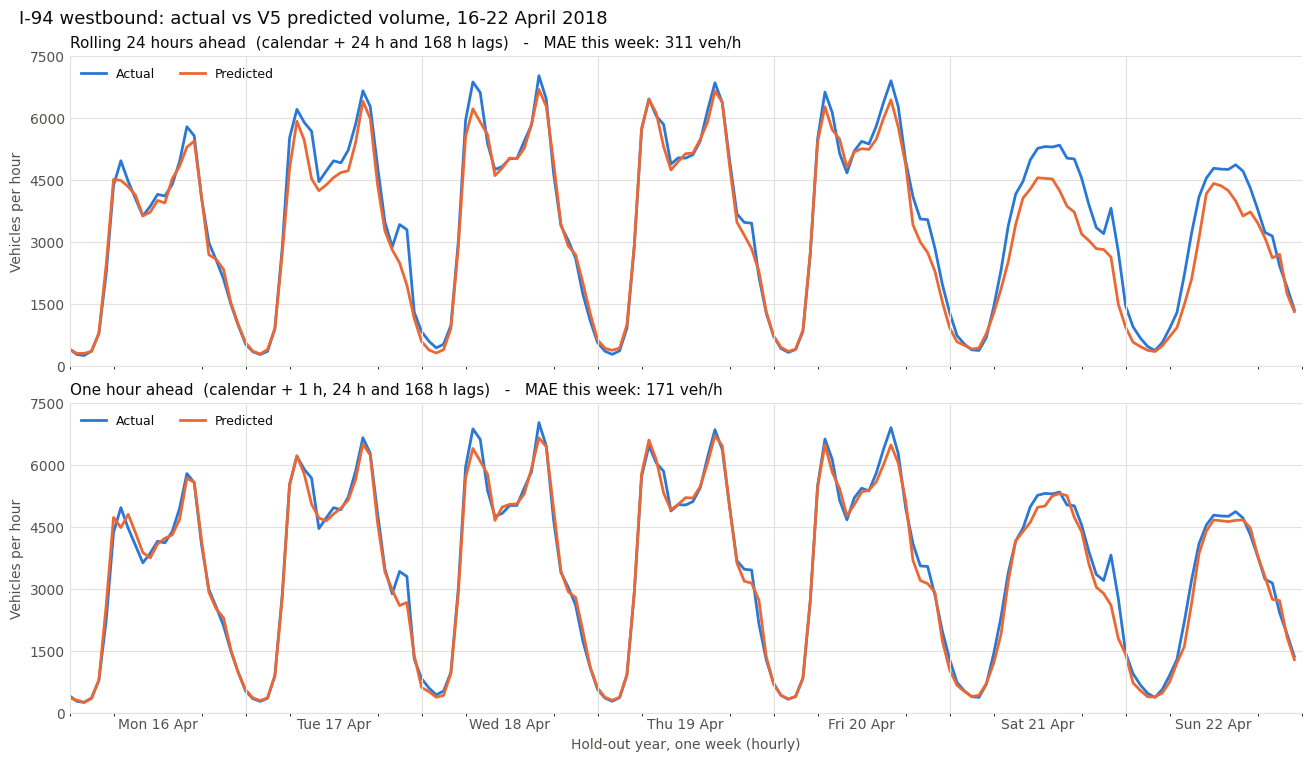

Saturday daytime (10:00-18:00) mean volume across 57 hold-out Saturdays: median 4,557, min 1,775, max 5,328 veh/h
  Sat 21 Apr 2018 (plotted)         : 5,026 veh/h  -> rank 10 of 57
  Sat 14 Apr 2018 (its 168 h lag)   : 1,775 veh/h  -> rank 57 of 57
  24 h ahead: week MAE 311 | weekdays 221 | weekend 538 veh/h
  1 h ahead: week MAE 171 | weekdays 153 | weekend 214 veh/h


In [50]:
# Actual vs predicted for one fixed, complete week of the hold-out year (Mon 16 - Sun 22 Apr 2018).
# Both panels show the deployable V5 models; the top one is the planning horizon.
import matplotlib.dates as mdates

week_start = pd.Timestamp("2018-04-16")                      # a Monday, no holiday, all 168 hours present
week_end   = week_start + pd.Timedelta(days=7)
mask = ((test_df["date_time"] >= week_start) & (test_df["date_time"] < week_end)).values

wk = test_df.loc[mask, ["date_time", "traffic_volume"]].copy()
wk["pred_24h"]  = np.asarray(v5_preds["V5 24 h-ahead: no weather, time-aware stack"])[mask]
wk["pred_hour"] = np.asarray(v5_preds["V5 1-hour-ahead: no weather, time-aware stack"])[mask]
assert len(wk) == 168, f"expected 168 hours, got {len(wk)}"

ACTUAL, PRED = "#2a78d6", "#eb6834"                          # categorical slots 1 and 2
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e2e1dd"

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True, constrained_layout=True)
panels = [("Rolling 24 hours ahead  (calendar + 24 h and 168 h lags)", "pred_24h"),
          ("One hour ahead  (calendar + 1 h, 24 h and 168 h lags)", "pred_hour")]

for ax, (title, col) in zip(axes, panels):
    ax.plot(wk["date_time"], wk["traffic_volume"], color=ACTUAL, lw=2, label="Actual")
    ax.plot(wk["date_time"], wk[col],              color=PRED,   lw=2, label="Predicted")
    week_mae = mean_absolute_error(wk["traffic_volume"], wk[col])
    ax.set_title(f"{title}   -   MAE this week: {week_mae:,.0f} veh/h", loc="left", fontsize=11, color=INK)
    ax.set_ylabel("Vehicles per hour", color=INK2)
    ax.set_ylim(0, 7500)
    ax.set_yticks(range(0, 7501, 1500))
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK2, length=0)
    for d in pd.date_range(week_start, week_end, freq="D")[1:-1]:      # midnight separators
        ax.axvline(d, color=GRID, lw=0.8)
    ax.legend(loc="upper left", frameon=False, ncol=2, fontsize=9, labelcolor=INK)

axes[-1].set_xlim(week_start, week_end)
axes[-1].xaxis.set_major_locator(mdates.HourLocator(byhour=[12]))     # label each day at noon, between separators
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
axes[-1].set_xlabel("Hold-out year, one week (hourly)", color=INK2)
fig.suptitle("I-94 westbound: actual vs V5 predicted volume, 16-22 April 2018", x=0.01, ha="left", fontsize=13, color=INK)
plt.show()

# --- Is the plotted Saturday unusual? Compare it with every Saturday in the hold-out year. ---
sat = test_df[(test_df["date_time"].dt.dayofweek == 5) & test_df["date_time"].dt.hour.between(10, 18)]
sat_means = sat.groupby(sat["date_time"].dt.date)["traffic_volume"].mean()
plotted, lag_week = pd.Timestamp("2018-04-21").date(), pd.Timestamp("2018-04-14").date()
print(f"Saturday daytime (10:00-18:00) mean volume across {len(sat_means)} hold-out Saturdays: "
      f"median {sat_means.median():,.0f}, min {sat_means.min():,.0f}, max {sat_means.max():,.0f} veh/h")
print(f"  Sat 21 Apr 2018 (plotted)         : {sat_means[plotted]:,.0f} veh/h  "
      f"-> rank {int((sat_means > sat_means[plotted]).sum() + 1)} of {len(sat_means)}")
print(f"  Sat 14 Apr 2018 (its 168 h lag)   : {sat_means[lag_week]:,.0f} veh/h  "
      f"-> rank {int((sat_means > sat_means[lag_week]).sum() + 1)} of {len(sat_means)}")

# Per-hour absolute error on the plotted week, by day type, for both horizons
wk_err = wk.assign(is_weekend=wk["date_time"].dt.dayofweek >= 5)
for col, label in [("pred_24h", "24 h ahead"), ("pred_hour", "1 h ahead")]:
    e = (wk[col] - wk["traffic_volume"]).abs()
    print(f"  {label}: week MAE {e.mean():,.0f} | weekdays {e[~wk_err.is_weekend.values].mean():,.0f} "
          f"| weekend {e[wk_err.is_weekend.values].mean():,.0f} veh/h")


**Reading the chart**

This is one week out of 57 in the hold-out year, chosen because it is complete and holiday-free. It illustrates the fit; it is not evidence about the model in general.

* **Both models track the weekday shape closely.** The 06:00 ramp, the morning peak, the midday dip and the taller late-afternoon peak all appear at the right hours on all five weekdays. Weekday MAE this week is 221 (24 h ahead) and 153 (1 h ahead) veh/h.
* **The weekend is harder for both, and much harder for the 24-hour-ahead model.** Weekend MAE is 538 veh/h at the 24-hour horizon against 221 on weekdays; at the one-hour horizon it is 214 against 153. The 24-hour-ahead line sits visibly below the actual through Saturday and Sunday afternoon.
* **Why this Saturday is hard is specific and checkable.** Saturday 21 April was *not* unusual: at 5,026 veh/h across 10:00–18:00 it ranks 10th of the 57 hold-out Saturdays, close to its neighbours on 7 April (5,025) and 28 April (5,034). What is unusual is its 168-hour lag. Saturday 14 April averaged 1,775 veh/h, the **lowest of all 57**; the dataset records 53 snow-coded hours over that weekend, including `heavy snow` and `sleet`, with temperatures between 23 and 39 °F. The weekly lag therefore fed the model the single worst Saturday in the year as its estimate for a normal one. The one-hour-ahead model recovers because its 1-hour lag reflects the actual day in progress; the 24-hour-ahead model has no such correction.
* **On apparent lag at turning points.** At the steepest transitions the predicted line can appear to trail the actual one, which would be the expected behaviour of a lag-driven model. This single week does not establish that: the offset is not consistent across days or across the two panels, and the visual gap at a steep ramp is also what a small vertical error looks like. Testing it properly would mean a cross-correlation of the residuals against the actual series over the full year, which is not done here.
* **Week MAEs (311 and 171) sit above the full-year figures (253 and 153)**, driven by the weekend rather than the weekdays.


In [51]:
from sklearn.metrics import r2_score

mae   = mean_absolute_error(y_test, stack_pred)
rmse  = root_mean_squared_error(y_test, stack_pred)
mean_ = y_test.mean()

mape = np.mean(np.abs(y_test - stack_pred) / np.clip(y_test, 1e-9, None))
nmae = mae / mean_
r2   = r2_score(y_test, stack_pred)

print(f"Test-set mean volume : {mean_:,.1f} veh/h")
print(f"MAE  : {mae:,.2f}  ->  nMAE = MAE / mean = {nmae:.3%}")
print(f"MAPE : {mape:.3%}")
print(f"R2   : {r2:.3f}")


Test-set mean volume : 3,345.5 veh/h
MAE  : 151.35  ->  nMAE = MAE / mean = 4.524%
MAPE : 6.278%
R2   : 0.986


## Interpreting the headline metrics

The cell above scores the V3 stack (one hour ahead, observed weather, `KFold` stacking). The deployable V5 figures are within 1–2 % of it, so the interpretation below uses the V5 numbers.

| Metric | V5 one hour ahead | V5 rolling 24 h ahead | What it entails |
|--------|------------------:|----------------------:|---------------|
| **MAE** | **153 veh/h** | **253 veh/h** | Average absolute miss per hour. |
| **nMAE** | **4.6 %** | **7.6 %** | MAE divided by the mean hourly volume of the test year (≈ 3 346 veh/h). |
| **RMSE** | **237 veh/h** | **465 veh/h** | Penalises the large misses; the wider RMSE-to-MAE ratio at 24 hours shows it is caught out more often by unusual days. |
| **R²** | **0.986** | **0.945** | Share of hourly variance explained on the hold-out year. |

The earlier draft reported "accuracy ≈ 90 %" figures derived as 1 − nMAE and 100 × R². Those are not standard accuracy measures for a regression task and have been removed.

### Practical takeaway

* For **live, next-hour** use (ramp metering, variable message signs) a typical miss of about 150 vehicles is a small fraction of a 6 000-vehicle peak, and the model needs nothing but the sensor's own history and the clock.
* For **planning 24 hours out**, quote MAE 253 / RMSE 465. That beats the hour × weekday lookup table (MAE 300, RMSE 529) and the calendar-only forest (MAE 285, RMSE 492), and it needs no weather forecast. Remember it is a rolling 24-hour offset, not a single next-day run.
* Percentage error is worst in the small hours; if night-shift scheduling matters, a separate low-flow model or a log-scale target would be the next experiment.
* The weakest point is an unusual *previous* week: when the 168-hour lag lands on an anomalous day, the 24-hour-ahead model inherits it. A production system would benefit from an outlier guard on the lag inputs.


## From "just fit a model" to a **temporal-aware ensemble**

| Stage | Feature set | Model | test MAE | test RMSE | What we learned |
|-------|-------------|-------|---------:|----------:|-----------------|
| **Baseline** | hour × day-of-week lookup | none | 300 | 529 | The weekly clock alone explains most of the variance. Anything that does not beat this has learned nothing. |
| **V1** | sin/cos hour, 4-level period bucket, day-of-week, weekend flag, weather buckets | **Ridge / Poisson GLM** | ≈ 780 / 804 | ≈ 974 / 1 008 | Linear models cannot reproduce the twin commuter peaks and lose to the hour-mean baseline. |
| **V1** | same | **Random Forest** | **289** | 512 | Non-linear splits recover the daily shape, but the forest only edges the lookup table by 11 MAE. |
| **V2** | + hour × rain / snow / weekend interactions, 3-level period bucket, period × day/temp/rain/snow/weekend composites | Ridge → 706, RF → 288, **Stacked (RF + XGB → Ridge)** → **283** | 283 | 503 | Interactions help the linear models a lot and the trees a little; stacking adds a further 1.8 %. |
| **V3** | V2 + **timestamp-aligned** lags at 1 h, 24 h, 168 h on de-duplicated rows | Stacked | 151 | 236 | Knowing the previous hour's count halves the error. One-hour-ahead horizon; uses observed weather. |
| **V4** | V2 + 24 h and 168 h lags | Stacked | 250 | 457 | Rolling 24-hour-ahead horizon; still uses observed weather at the target hour. |
| **V5** | calendar + lags only, **no weather**, time-aware non-negative stacking | **Stacked** | **153** (1 h) / **253** (24 h) | **237** / **465** | The deployable numbers. Removing weather costs 1–2 %; the stacking rework costs nothing measurable. |
| *Reference* | calendar only, no weather, no lags | Random Forest | 285 | 492 | The like-for-like baseline the lags are worth 11 % against. |

### Key improvement milestones

1. **Establish the baselines first.** The 168-cell lookup table sets a demanding bar (MAE 300); both linear models fail to clear even the 24-cell version.
2. **Move beyond linearity.** Random Forest proves the daily profile is highly non-linear, cutting MAE by 63 % versus Ridge.
3. **Keep the clock, add interactions.** Hour sin/cos must stay in the feature set; composites and hour × condition terms are what let Ridge improve by 9 %.
4. **Stack carefully.** RF + XGBoost blended by a Ridge meta-learner gives a small, consistent gain (about 2 %) on the same features.
5. **Autoregressive memory, aligned by time.** Building lags by timestamp lookup on de-duplicated rows (not by positional `shift`, which mixed duplicate and missing hours) is the single biggest upgrade. The gain is horizon-dependent: −46 % MAE one hour ahead, −11 % at 24 hours against a calendar-only baseline.
6. **Validate like it will be deployed, and say what was actually measured.** Out-of-fold predictions must come from the past only; features must be things the forecaster will really have; the reference model must differ from the candidate in exactly one respect; and a rolling fixed-offset evaluation is not the same thing as a single forecast issued for a whole day.

### Bottom-line impact

* **Deployable one-hour-ahead error**: ± 153 veh/h (RMSE 237, R² 0.986). **Deployable rolling 24-hour-ahead error**: ± 253 veh/h (RMSE 465, R² 0.945). Both use only the calendar and the sensor's own history.
* **Weather is not needed.** Removing observed target-hour weather costs 1–2 %; adding it to a calendar-only forest buys 6.8 MAE. Either way the model does not depend on a weather forecast.
* **On generalisation**: training error understates test error by 7 % (1 h) to 16–18 % RMSE (24 h) and is not used for any claim; time-series CV lands within 2 % (24 h) to 8 % (1 h) of the hold-out year.
* **Known limits**: the 24-hour-ahead model inherits anomalies in its 168-hour lag (the 21 April week in the chart above is a clean example), and neither horizon has been tested as a fixed-issue-time next-day forecast.
* Data hygiene mattered as much as modelling: duplicate timestamps, a 10-month sensor gap, ten 0 K temperature rows and one impossible rain reading all had to be handled before the lag features meant what their names say.
